In [7]:
import polars as pl
import polars.selectors as cs
import gc

from datetime import datetime
from typing import Optional, Dict, Any
import json

import matplotlib.pyplot as plt
import seaborn as sns

import re

In [8]:
pl.Config.set_tbl_rows(-1)     
pl.Config.set_tbl_cols(-1)    
pl.Config.set_tbl_width_chars(200)  
pl.Config.set_fmt_str_lengths(50)  

polars.config.Config

In [9]:
DATA_ROOT = "D:\\Projects\\Coding\\Notebooks\\Projects\\labor_market_analysis\\data\\raw\\"
VACANCY_ROOT = DATA_ROOT + "vacancies_trudvsem.csv"

In [10]:
def read_csv(file_path: str, schema_overrides=None) -> pl.DataFrame:
    
    df = pl.read_csv(
        file_path,
        encoding='utf-8',
        separator='|',
        try_parse_dates=True,
        ignore_errors=True,
        null_values=['', 'NULL', 'null', 'None', 'N/A', 'не указано'],
        truncate_ragged_lines=True,
        infer_schema_length=10000,
        quote_char=None,
        low_memory=True,
        schema_overrides=schema_overrides,
    )
    
    print(f"Загружено: {df.height:,} строк, {df.width} колонок")

    return df

In [11]:
def read_vacancies_csv(file_path: str) -> pl.DataFrame:
    
    # Явное указание типов данных для экономии памяти
    schema_overrides = {
        'salaryMin': pl.Float32,
        'salaryMax': pl.Float32,
        'workPlaces': pl.Int32,
        'experienceRequirements': pl.Float32,
        
        'state_region_code': pl.Int32,
        'company_code': pl.Int32,
        'code_profession': pl.Int32,
        #'federalDistrictCode': pl.Int16,
        
        'deleted': pl.Boolean,
        'isModerated': pl.Boolean,
        'isQuoted': pl.Boolean,
        'isMobilityProgram': pl.Boolean,
        'foreignWorkersCapability': pl.Boolean,
        'isUzbekistanRecruitment': pl.Boolean,
        'careerPerspective': pl.Boolean,
        'retrainingCapability': pl.Boolean,
        'accommodationCapability': pl.Boolean,
        
        'busyType': pl.Categorical,
        'scheduleType': pl.Categorical,
        'educationRequirements': pl.Categorical,
        'companyBusinessSize': pl.Categorical,
        'sourceType': pl.Categorical,
        'status': pl.Categorical,
        'visibility': pl.Categorical,
    }
    
    df = read_csv(file_path, schema_overrides)
    
    salary_cols = ['salaryMin', 'salaryMax', 'salary']
    for col in salary_cols:
        if col in df.columns:
            df = df.with_columns(
                pl.col(col)
                .cast(pl.String, strict=False)
                .str.replace_all(r'[^\d.]', '')
                .cast(pl.Float32, strict=False)
            )
    
    df = df.filter(
    (pl.col('deleted') == False) &
    (pl.col('status') == 'Одобрено') &
    (pl.col('visibility') == 'Видно всем')
    )
    
    print(f"После фильтрации: {df.height:,} строк")
    
    gc.collect()
    
    return df

In [12]:
vacancies_df = read_vacancies_csv(VACANCY_ROOT)

Загружено: 452,979 строк, 80 колонок
После фильтрации: 452,506 строк


# **ПЕРВИЧНЫЙ АНАЛИЗ**

In [74]:
vacancies_df.head(5)

id,stateRegionCode,vacancyName,codeProfession,codeProfessionalSphere,professionalSphereName,vacancyAddress,vacancyAddressHouse,vacancyAddressAdditionalInfo,geo,salary,socialProtecteds,languageKnowledge,busyType,educationRequirements,hardSkills,softSkills,skills,typicalPosition,experienceRequirements,scheduleType,premium,otherVacancyBenefit,careerPerspective,codeExternalSystem,idPriorityCategory,needMedcard,sourceType,requiredСertificates,requiredDriveLicense,retrainingCapability,retrainingСondition,retrainingGrantValue,transportCompensation,changeTime,contactPerson,contactSource,company,fullCompanyName,oknpoCode,oksoCode,companyBusinessSize,dateModify,workPlaces,isUzbekistanRecruitment,federalDistrictCode,industryBranchName,datePublished,accommodationCapability,accommodationType,foreignWorkersCapability,metroIds,isQuoted,creationDate,isMobilityProgram,isModerated,deleted,visibility,regionName,status,vacancyUrl,positionRequirements,contactList,additionalRequirements,salaryMin,salaryMax,qualifications,responsibilities,addressCode,addressOffice,hireDate,workPlace,medicalCertificate,scheduleTypeComment,benefitDetails,trainingDays,shift,medicalDocument,benefit,conditions
str,i64,str,i64,str,str,str,str,str,str,f32,str,str,cat,cat,str,str,str,str,f32,cat,str,str,bool,str,str,str,cat,str,str,bool,str,i64,str,"datetime[μs, UTC]",str,str,str,str,str,i64,cat,"datetime[μs, UTC]",i32,bool,i64,str,"datetime[μs, UTC]",bool,str,bool,str,bool,"datetime[μs, UTC]",bool,bool,bool,cat,str,cat,str,str,str,str,f32,f32,str,str,i64,str,"datetime[μs, UTC]",str,str,str,str,i64,str,str,str,str
"""94025018-684f-11f0-98c4-d549be31d974""",7200000000000,"""Техник-дозиметрист отдела радиационной безопасност…",269277,"""Medicine""","""Здравоохранение и социальное обеспечение""","""Тюменская область, Город Тюмень, Юрия Семовских ул…","""14""",null,"""{""latitude"": 57.099834, ""longitude"": 65.548359}""",42000.0,null,"""[]""","""Полная занятость""","""{""educationType"": ""Среднее профессиональное образо…","""[]""","""[]""","""[]""","""Ничего не выбрано""",0.0,"""Полный рабочий день""","""{}""",null,false,null,null,"""Не указано""","""Работодатель""",null,"""[]""",null,null,null,null,2025-07-24 05:32:38 UTC,"""Григорьева Наталья Александровна""",null,"""{""companyCode"": ""d4004160-74c4-11ea-ace8-e37b4be0b…","""ГОСУДАРСТВЕННОЕ АВТОНОМНОЕ УЧРЕЖДЕНИЕ ЗДРАВООХРАНЕ…",null,null,"""LARGE""",2025-10-20 04:19:11 UTC,1,false,5,null,2025-10-20 04:19:11 UTC,false,null,false,null,false,2025-07-24 05:32:24 UTC,null,true,false,"""Видно всем""","""Тюменская область""","""Одобрено""","""https://trudvsem.ru/vacancy/card/d4004160-74c4-11e…","""среднее профессиональное техническое образование б…","""[{""contactType"": ""Телефон"", ""contactValue"": ""+7(34…",null,42000.0,45000.0,"""среднее профессиональное техническое образование б…","""Осуществлять контроль за мощностью дозы гамма-излу…",72000001000172400,null,null,"""{""workPlaceForeign"": false, ""workPlaceOrdinary"": t…",null,null,null,0,"""[]""","""Медицинская книжка""",null,null
"""90778f18-781b-11f0-a9f5-d549be31d974""",7200000000000,"""Медицинская сестра по медицинской реабилитации отд…",240387,"""Medicine""","""Здравоохранение и социальное обеспечение""","""Тюменская область, Город Тюмень, Барнаульская улиц…","""дом: Д.32;""",null,"""{""latitude"": 57.166754, ""longitude"": 65.467367}""",51300.0,null,"""[]""","""Полная занятость""","""{""educationType"": ""Среднее профессиональное образо…","""[]""","""[]""","""[]""","""Медицинская сестра""",0.0,"""Полный рабочий день""","""{}""",null,false,null,null,"""Не указано""","""Работодатель""",null,"""[]""",null,null,null,null,2025-08-13 08:00:32 UTC,"""Григорьева Наталья Александровна""",null,"""{""companyCode"": ""d4004160-74c4-11ea-ace8-e37b4be0b…","""ГОСУДАРСТВЕННОЕ АВТОНОМНОЕ УЧРЕЖДЕНИЕ ЗДРАВООХРАНЕ…",null,3340201,"""LARGE""",2025-10-20 04:19:44 UTC,1,false,5,null,2025-10-20 04:19:44 UTC,false,null,false,null,false,2025-08-13 08:00:23 UTC,null,true,false,"""Видно всем""",""

**Зарплаты**

In [8]:
# Колонки с данными о зарплате
vacancies_df.select(cs.contains("salary"))[:5]

salary,salaryMin,salaryMax
f32,f32,f32
42000.0,42000.0,45000.0
51300.0,51300.0,56000.0
0.0,0.0,0.0
0.0,0.0,0.0
49000.0,49000.0,60000.0


In [9]:
# Число строк где salaryMin == salaryMax
vacancies_df.filter(pl.col("salaryMin") == pl.col("salaryMax")).height

177723

**Даты**

In [10]:
# Колонки в названии которых есть "date" или "Date"
vacancies_df.select(cs.contains("Date") | cs.contains("date"))[:5]

dateModify,datePublished,creationDate,hireDate
"datetime[μs, UTC]","datetime[μs, UTC]","datetime[μs, UTC]","datetime[μs, UTC]"
2025-10-20 04:19:11 UTC,2025-10-20 04:19:11 UTC,2025-07-24 05:32:24 UTC,null
2025-10-20 04:19:44 UTC,2025-10-20 04:19:44 UTC,2025-08-13 08:00:23 UTC,null
2025-12-06 03:06:16 UTC,2025-12-06 03:06:16 UTC,2025-11-12 12:10:36 UTC,null
2025-12-10 07:55:24 UTC,2025-12-10 07:55:24 UTC,2025-12-10 07:55:24 UTC,null
2025-10-20 04:19:26 UTC,2025-10-20 04:19:26 UTC,2025-06-18 10:32:07 UTC,null


In [11]:
print(f"Самая ранняя дата создания вакансии: {vacancies_df.select(pl.col("creationDate").min()).item()}")

Самая ранняя дата создания вакансии: 2015-06-27 07:54:17+00:00


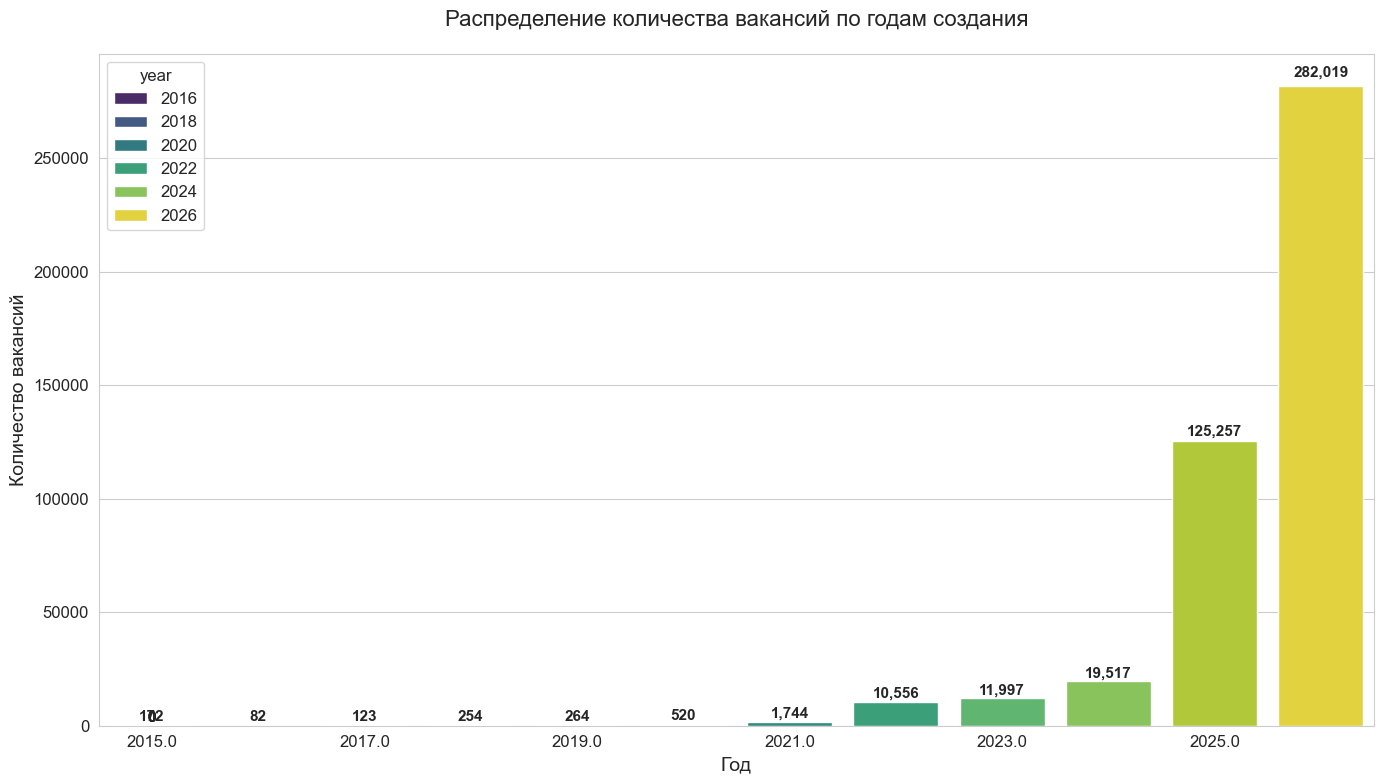

Распределение вакансий по годам:
shape: (13, 2)
┌──────┬────────┐
│ year ┆ count  │
│ ---  ┆ ---    │
│ i32  ┆ u32    │
╞══════╪════════╡
│ null ┆ 1      │
│ 2015 ┆ 172    │
│ 2016 ┆ 82     │
│ 2017 ┆ 123    │
│ 2018 ┆ 254    │
│ 2019 ┆ 264    │
│ 2020 ┆ 520    │
│ 2021 ┆ 1744   │
│ 2022 ┆ 10556  │
│ 2023 ┆ 11997  │
│ 2024 ┆ 19517  │
│ 2025 ┆ 125257 │
│ 2026 ┆ 282019 │
└──────┴────────┘


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl


VACANCY_ROOT = "D:\\Projects\\Coding\\Notebooks\\Projects\\labor_market_analysis\\data\\raw"
vacancies_df = read_vacancies_csv(VACANCY_ROOT)

# Настройка стилей для графиков
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

# 1. Извлекаем год из колонки creationDate
# Создаем новый датафрейм с подсчетом количества вакансий по годам
vacancies_by_year = (
    vacancies_df
    .with_columns(pl.col('creationDate').dt.year().alias('year'))
    .group_by('year')
    .agg(pl.len().alias('count'))
    .sort('year')
)

# Конвертируем в pandas для удобной работы с seaborn (опционально, можно и через polars.plot)
df_plot = vacancies_by_year.to_pandas()

# 2. Построение графика
fig, ax = plt.subplots()

# Столбчатая диаграмма
bars = sns.barplot(
    data=df_plot,
    x='year',
    y='count',
    hue='year',
    palette='viridis',
    ax=ax
)

# Добавление подписей значений на столбцы
for bar in bars.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.,
        height + max(height * 0.01, 500), # Небольшой отступ сверху
        f'{int(height):,}', # Форматирование с разделителями тысяч
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Оформление графика
ax.set_title('Распределение количества вакансий по годам создания', fontsize=16, pad=20)
ax.set_xlabel('Год', fontsize=14)
ax.set_ylabel('Количество вакансий', fontsize=14)

# Форматирование оси X, чтобы годы отображались как целые числа
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Поворот подписей лет, если их много (опционально)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# Вывод статистики в консоль
print("Распределение вакансий по годам:")
print(vacancies_by_year)

**Образование**

In [13]:
vacancies_df.select(cs.contains("education"))[:5]

educationRequirements
cat
"""{""educationType"": ""Среднее профессиональное образо…"
"""{""educationType"": ""Среднее профессиональное образо…"
"""{""educationType"": ""Не указано""}"""
"""{""educationType"": ""Не указано""}"""
"""{""educationType"": ""Среднее профессиональное образо…"


In [14]:
vacancies_df['educationRequirements'].value_counts(sort=True)[:10]

educationRequirements,count
cat,u32
"""{""educationType"": ""Среднее профессиональное образо…",119973
"""{""educationType"": ""Общее образование""}""",60415
"""{""educationType"": ""Tребования не предъявляются""}""",53000
"""{""educationType"": ""Не указано""}""",37211
"""{""educationType"": ""Высшее образование — бакалавриа…",36064
"""{""educationType"": ""Высшее образование — специалите…",19515
"""{""educationType"": ""Среднее профессиональное образо…",5161
"""{""educationType"": ""Высшее образование — бакалавриа…",3573
"""{""educationType"": ""Высшее образование — подготовка…",3006


In [ ]:
for i in vacancies_df["educationRequirements"].unique()[:10]:
    print(i)

**Язык**

In [16]:
vacancies_df['languageKnowledge'].value_counts(sort=True)[3]["languageKnowledge"].item()

'[{"code_language": "Русский", "id_owner": "bd9998ac-0199-11f1-9f31-ab1bbbf5ae25", "type": "LanguageKnowledge"}]'

**Навыки**

In [17]:
vacancies_df['softSkills'].value_counts(sort=True)[:4]

softSkills,count
str,u32
"""[]""",451574
"""[""Работа в команде""]""",186
"""[""Внимательность к деталям""]""",72
"""[""Работоспособность""]""",65


In [18]:
vacancies_df['hardSkills'].value_counts(sort=True)[:4]

hardSkills,count
str,u32
"""[]""",441606
"""[""умение работать в команде""]""",425
"""[""ответственность""]""",396
"""[""ответственность за достижение результата""]""",382


In [19]:
vacancies_df['skills'].value_counts(sort=True)[:4]

skills,count
str,u32
"""[]""",381465
"""[""Ответственность , добросовестность"", ""Ответствен…",1319
"""[""Обучение обучающихся"", ""Обучение обучающихся""]""",268
"""[""Обслуживание и ремонт электрооборудования"", ""Обс…",238


**Размер компании**

In [20]:
vacancies_df['companyBusinessSize'].value_counts(sort=True)

companyBusinessSize,count
cat,u32
"""SMALL""",301964
"""LARGE""",73157
"""MIDDLE""",31080
"""BIG""",24088
"""MICRO""",22217


**Премии**

In [21]:
vacancies_df['premium'].value_counts(sort=True)[:4]

premium,count
str,u32
"""{}""",427902
"""{""premiumSize"": 30, ""premiumType"": ""MONTHLY""}""",3109
"""{""premiumSize"": 25, ""premiumType"": ""MONTHLY""}""",2224
"""{""premiumSize"": 50, ""premiumType"": ""MONTHLY""}""",1248


In [22]:
vacancies_df['regionName'].value_counts(sort=True)[:]

regionName,count
str,u32
"""Краснодарский край""",20051
"""Свердловская область""",15227
"""Город Москва""",14415
"""Самарская область""",13336
"""Город Санкт-Петербург""",12095
"""Ростовская область""",11132
"""Красноярский край""",11072
"""Московская область""",10950
"""Нижегородская область""",10328


## Анализ пропусков

In [23]:
def analyze_nulls(df: pl.DataFrame) -> pl.DataFrame:
    """
    Заменяет строковые значения '[]' и '{}' на null, считает пропуски 
    и выводит статистику по колонкам в порядке убывания процента пропусков.
    
    Параметры:
    df (pl.DataFrame): Исходный датафрейм Polars.
    
    Возвращает:
    pl.DataFrame: Датафрейм со статистикой пропусков (column, null_count, null_percentage).
    """
    
    # 1. Замена '[]' и '{}' на null
    string_columns = [col for col in df.columns if df[col].dtype == pl.String]
    
    if string_columns:
        df = df.with_columns(
            [
                pl.col(col).replace(['[]', '{}'], None).alias(col)
                for col in string_columns
            ]
        )
    else:
        print("Строковые колонки для замены не найдены.")

    # 2. Подсчет количества пропусков (null) для каждой колонки
    null_counts = df.select([pl.col(col).null_count().alias(col) for col in df.columns])
    
    stats_df = null_counts.transpose(include_header=True, header_name="column")
    stats_df = stats_df.rename({"column_0": "null_count"})
    
    stats_df = stats_df.with_columns([
        pl.col("null_count").cast(pl.Int64),
        pl.lit(df.height).alias("total_rows")
    ])
    
    # 3. Расчет относительного количества пропусков (в процентах)
    stats_df = stats_df.with_columns(
        ((pl.col("null_count") / pl.col("total_rows")) * 100).round(2).alias("null_percentage")
    )

    stats_df = stats_df.sort("null_percentage", descending=True)
    result_stats = stats_df.select(["column", "null_count", "null_percentage"])
        
    return result_stats

In [77]:
nulls = analyze_nulls(vacancies_df)
nulls

column,null_count,null_percentage
str,i64,f64
"""requiredСertificates""",452506,100.0
"""retrainingСondition""",452506,100.0
"""oknpoCode""",452506,100.0
"""industryBranchName""",452506,100.0
"""softSkills""",451574,99.79
"""retrainingGrantValue""",451202,99.71
"""idPriorityCategory""",451038,99.68
"""benefitDetails""",448786,99.18
"""contactSource""",446776,98.73


# **ПРОВЕРКА ГИПОТЕЗ**

## H1: Доминирование малого бизнеса в потоке вакансий

Более 60% всех активных вакансий размещаются компаниями категорий MICRO (<50 сотрудников) и **SMALL** (51–100 сотрудников), тогда как доля компаний категории **LARGE** (>500 сотрудников) составляет менее 15% от общего числа публикаций, несмотря на их значительный объем штата.

In [25]:
# Настройка стилей для графиков
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 12

# 1. Создаем рабочую копию датафрейма для анализа гипотезы H1
df_h1 = vacancies_df.clone()

# 2. Дополнительная очистка поля companyBusinessSize (на случай скрытых пробелов или нестандартных значений)
# Хотя анализ nulls показал 0% пропусков, убедимся, что категория приведена к строке для надежности
df_h1 = df_h1.with_columns(
    pl.col("companyBusinessSize").cast(pl.String).str.strip_chars().alias("companyBusinessSize_clean")
)

# 3. Группировка и подсчет количества вакансий по размеру компании
size_distribution = (
    df_h1
    .group_by("companyBusinessSize_clean")
    .agg(pl.len().alias("vacancy_count"))
    .with_columns(
        (pl.col("vacancy_count") / pl.col("vacancy_count").sum() * 100).round(2).alias("percentage")
    )
    .sort("percentage", descending=True)
)

# Вывод таблицы с распределением
print("Распределение вакансий по размеру компании:")
print(size_distribution)

Распределение вакансий по размеру компании:
shape: (5, 3)
┌───────────────────────────┬───────────────┬────────────┐
│ companyBusinessSize_clean ┆ vacancy_count ┆ percentage │
│ ---                       ┆ ---           ┆ ---        │
│ str                       ┆ u32           ┆ f64        │
╞═══════════════════════════╪═══════════════╪════════════╡
│ SMALL                     ┆ 301964        ┆ 66.73      │
│ LARGE                     ┆ 73157         ┆ 16.17      │
│ MIDDLE                    ┆ 31080         ┆ 6.87       │
│ BIG                       ┆ 24088         ┆ 5.32       │
│ MICRO                     ┆ 22217         ┆ 4.91       │
└───────────────────────────┴───────────────┴────────────┘


In [26]:
# Извлекаем значения для расчетов
# Преобразуем результат в словарь для удобного доступа
stats_dict = size_distribution.select(
    pl.col("companyBusinessSize_clean"), 
    pl.col("percentage")
).rows(named=True)

# Создаем словарь {размер: процент}
data_map = {row["companyBusinessSize_clean"]: row["percentage"] for row in stats_dict}

# Расчет метрик
micro_share = data_map.get("MICRO", 0)
small_share = data_map.get("SMALL", 0)
large_share = data_map.get("LARGE", 0)

# Суммарная доля малого бизнеса
small_business_total = micro_share + small_share

print(f"--- Результаты проверки Гипотезы H1 ---")
print(f"Доля MICRO (<50 сотр.): {micro_share:.2f}%")
print(f"Доля SMALL (51-100 сотр.): {small_share:.2f}%")
print(f"Суммарная доля малого бизнеса (MICRO + SMALL): {small_business_total:.2f}%")
print(f"Доля LARGE (>500 сотр.): {large_share:.2f}%")
print("-----------------------------------------")

# Проверка условий гипотезы
h1_condition_1 = small_business_total > 60.0
h1_condition_2 = large_share < 15.0

print(f"\nУсловие 1 (Малый и очень малый бизнес > 60%): {'ВЫПОЛНЕНО' if h1_condition_1 else 'НЕ ВЫПОЛНЕНО'} ({small_business_total:.2f}%)")
print(f"Условие 2 (Крупный бизнес < 15%): {'ВЫПОЛНЕНО' if h1_condition_2 else 'НЕ ВЫПОЛНЕНО'} ({large_share:.2f}%)")

if h1_condition_1 and h1_condition_2:
    print("\nГИПОТЕЗА H1 ПОДТВЕРЖДЕНА")
else:
    print("\nГИПОТЕЗА H1 ОПРОВЕРГНУТА (или требует уточнения)")

--- Результаты проверки Гипотезы H1 ---
Доля MICRO (<50 сотр.): 4.91%
Доля SMALL (51-100 сотр.): 66.73%
Суммарная доля малого бизнеса (MICRO + SMALL): 71.64%
Доля LARGE (>500 сотр.): 16.17%
-----------------------------------------

Условие 1 (Малый и очень малый бизнес > 60%): ВЫПОЛНЕНО (71.64%)
Условие 2 (Крупный бизнес < 15%): НЕ ВЫПОЛНЕНО (16.17%)

ГИПОТЕЗА H1 ОПРОВЕРГНУТА (или требует уточнения)


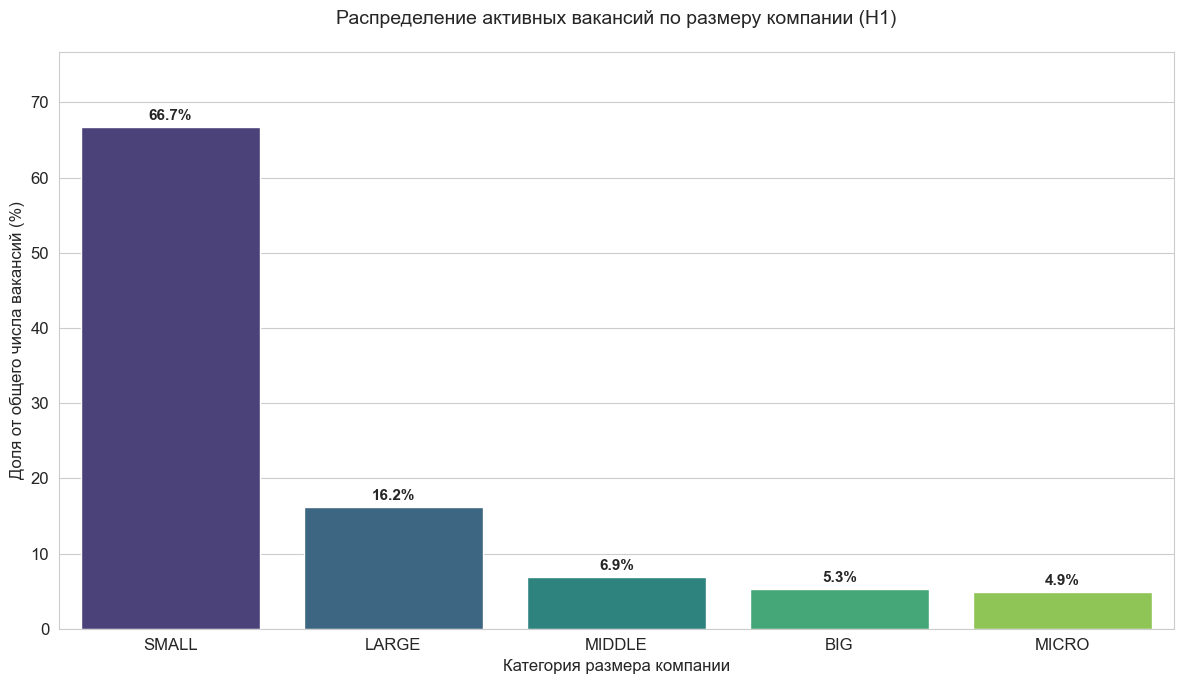

In [27]:
# Подготовка данных для графика
plot_data = size_distribution.to_pandas()

# Создание графика
fig, ax = plt.subplots()

# Столбчатая диаграмма
bars = sns.barplot(
    data=plot_data, 
    x="companyBusinessSize_clean", 
    y="percentage",
    hue="companyBusinessSize_clean",
    palette="viridis", 
    ax=ax
)

# Добавление подписей значений на столбцы
for bar in bars.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2., 
        height + 0.5, 
        f'{height:.1f}%', 
        ha='center', 
        va='bottom', 
        fontsize=11, 
        fontweight='bold'
    )

# Оформление графика
ax.set_title('Распределение активных вакансий по размеру компании (H1)', fontsize=14, pad=20)
ax.set_xlabel('Категория размера компании', fontsize=12)
ax.set_ylabel('Доля от общего числа вакансий (%)', fontsize=12)
ax.set_ylim(0, max(plot_data['percentage']) * 1.15) # Запас сверху для подписей

plt.tight_layout()
plt.show()

## H2: Региональный разрыв в требованиях к образованию

В экономических центрах (Москва, СПб, Татарстан) доля вакансий с требованием высшего образования статистически значимо выше (на 20%+), чем в регионах СКФО и ДФО, где преобладают требования к среднему профессиональному образованию или опыту без диплома.

### Парсинг educationRequirements

In [28]:
# Функция для безопасного парсинга JSON-строки
def parse_education_json(json_str: Optional[str]) -> Optional[str]:
    """
    Извлекает educationType из JSON-строки поля educationRequirements.
    Возвращает None если строка пуста, null или невалидный JSON.
    """
    if json_str is None or json_str == '' or json_str == 'null':
        return None
    
    try:
        # Удаляем лишние пробелы и пытаемся распарсить
        data = json.loads(json_str.strip())
        if isinstance(data, dict):
            return data.get('educationType', None)
        return None
    except (json.JSONDecodeError, TypeError, AttributeError):
        return None

# Функция для маппинга значений образования в стандартизированные категории
def map_education_type(edu_type: Optional[str]) -> str:
    """
    Приводит различные варианты написания образования к стандартным категориям.
    
    Категории:
    - HIGH: Высшее образование (все варианты)
    - MIDDLE_SPECIAL: Среднее профессиональное
    - MIDDLE: Среднее общее
    - NONE: Требования не предъявляются / Не указано
    """
    if edu_type is None:
        return 'NONE'
    
    edu_lower = edu_type.lower()
    
    # Высшее образование (все варианты)
    high_keywords = ['высшее', 'бакалавриат', 'специалитет', 'магистратура', 'аспирантура', 'доктор']
    if any(keyword in edu_lower for keyword in high_keywords):
        return 'HIGH'
    
    # Среднее профессиональное
    middle_special_keywords = ['среднее профессиональное', 'спО', 'колледж', 'техникум']
    if any(keyword in edu_lower for keyword in middle_special_keywords):
        return 'MIDDLE_SPECIAL'
    
    # Среднее общее (школа)
    middle_keywords = ['среднее общее', '11 классов', '9 классов', 'общее образование']
    if any(keyword in edu_lower for keyword in middle_keywords):
        return 'MIDDLE'
    
    # Не указано / Требования не предъявляются
    none_keywords = ['не указано', 'требования не предъявляются', 'не имеет значения', 'любое']
    if any(keyword in edu_lower for keyword in none_keywords):
        return 'NONE'
    
    # По умолчанию — NONE (консервативный подход)
    return 'NONE'

In [29]:
# Создаем копию датасета для работы
df_h2 = vacancies_df.clone()

# Шаг 1: Извлекаем educationType из JSON-строки
# Используем map_elements для применения функции к каждой ячейке
df_h2 = df_h2.with_columns(
    pl.col('educationRequirements')
    .map_elements(parse_education_json, return_dtype=pl.String)
    .alias('education_type_raw')
)

# Шаг 2: Маппим извлеченные значения в стандартизированные категории
df_h2 = df_h2.with_columns(
    pl.col('education_type_raw')
    .map_elements(map_education_type, return_dtype=pl.Categorical)
    .alias('education_category')
)

# Проверка результата — первые 10 строк
print("Пример распарсенных данных:")
display_df = df_h2.select(['educationRequirements', 'education_type_raw', 'education_category']).head(10)
print(display_df)

Пример распарсенных данных:
shape: (10, 3)
┌─────────────────────────────────────────────────────┬──────────────────────────────────────┬────────────────────┐
│ educationRequirements                               ┆ education_type_raw                   ┆ education_category │
│ ---                                                 ┆ ---                                  ┆ ---                │
│ cat                                                 ┆ str                                  ┆ cat                │
╞═════════════════════════════════════════════════════╪══════════════════════════════════════╪════════════════════╡
│ {"educationType": "Среднее профессиональное образо… ┆ Среднее профессиональное образование ┆ MIDDLE_SPECIAL     │
│ {"educationType": "Среднее профессиональное образо… ┆ Среднее профессиональное образование ┆ MIDDLE_SPECIAL     │
│ {"educationType": "Не указано"}                     ┆ Не указано                           ┆ NONE               │
│ {"educationType": "Не указа

In [30]:
# Проверка распределения по категориям образования
education_stats = (
    df_h2
    .group_by('education_category')
    .agg(pl.len().alias('vacancy_count'))
    .with_columns(
        (pl.col('vacancy_count') / pl.col('vacancy_count').sum() * 100).round(2).alias('percentage')
    )
    .sort('vacancy_count', descending=True)
)

print("\nРаспределение вакансий по категориям образования:")
print(education_stats)

# Проверка на наличие некорректных значений
null_check = df_h2.filter(pl.col('education_category').is_null())
print(f"\nКоличество записей с null в education_category: {null_check.height}")

# Проверка уникальных значений в raw-поле (для отладки)
print("\nУникальные значения education_type_raw (топ-15):")
raw_stats = df_h2['education_type_raw'].value_counts(sort=True).head(15)
print(raw_stats)


Распределение вакансий по категориям образования:
shape: (4, 3)
┌────────────────────┬───────────────┬────────────┐
│ education_category ┆ vacancy_count ┆ percentage │
│ ---                ┆ ---           ┆ ---        │
│ cat                ┆ u32           ┆ f64        │
╞════════════════════╪═══════════════╪════════════╡
│ MIDDLE_SPECIAL     ┆ 174442        ┆ 38.55      │
│ HIGH               ┆ 122097        ┆ 26.98      │
│ NONE               ┆ 91800         ┆ 20.29      │
│ MIDDLE             ┆ 64167         ┆ 14.18      │
└────────────────────┴───────────────┴────────────┘

Количество записей с null в education_category: 0

Уникальные значения education_type_raw (топ-15):
shape: (13, 2)
┌─────────────────────────────────────────────────────┬────────┐
│ education_type_raw                                  ┆ count  │
│ ---                                                 ┆ ---    │
│ str                                                 ┆ u32    │
╞══════════════════════════════════════

In [31]:
# Сохраняем подготовленный датасет с распарсенным образованием
# (опционально, если нужно использовать в других ячейках)
print(f"Датасет готов для проверки гипотезы H2")
print(f"Всего записей: {df_h2.height:,}")
print(f"Категории образования: {df_h2['education_category'].n_unique()}")

# Список категорий для использования в гипотезе H2
print("\nКатегории для анализа H2:")
print("- HIGH: Высшее образование")
print("- MIDDLE_SPECIAL: Среднее профессиональное")
print("- MIDDLE: Среднее общее")
print("- NONE: Не указано / Требования не предъявляются")

Датасет готов для проверки гипотезы H2
Всего записей: 452,506
Категории образования: 4

Категории для анализа H2:
- HIGH: Высшее образование
- MIDDLE_SPECIAL: Среднее профессиональное
- MIDDLE: Среднее общее
- NONE: Не указано / Требования не предъявляются


### Группировка регионов

In [32]:
result = (
    vacancies_df.filter(
        pl.col("regionName").is_in(["Дагестан", "Якутия", "Республика Дагестан", "Республика Саха (Якутия)"])
    )
    .select("regionName", "federalDistrictCode")
    .unique()
)

print(result)

shape: (2, 2)
┌──────────────────────────┬─────────────────────┐
│ regionName               ┆ federalDistrictCode │
│ ---                      ┆ ---                 │
│ str                      ┆ i64                 │
╞══════════════════════════╪═════════════════════╡
│ Республика Дагестан      ┆ 8                   │
│ Республика Саха (Якутия) ┆ 7                   │
└──────────────────────────┴─────────────────────┘


In [33]:
# Коды федеральных округов (согласно стандартной классификации РФ)
# СКФО (Северо-Кавказский) = 38, ДФО (Дальневосточный) = 42
SKFO_DFO_CODES = [7, 8]

# Регионы группы А (экономические центры) - точные названия из датасета
GROUP_A_REGIONS = [
    "Город Москва",
    "Город Санкт-Петербург", 
    "Республика Татарстан (Татарстан)"
]

# Функция для классификации региона
def classify_region(region_name: str, federal_district_code: int) -> str:
    """
    Классифицирует регион на группу для гипотезы H2.
    
    Возвращает:
    - 'GROUP_A': Экономические центры (Москва, СПб, Татарстан)
    - 'GROUP_B': СКФО и ДФО
    - 'OTHER': Все остальные регионы
    """
    # Приоритет: сначала проверяем конкретные регионы (Группа А)
    if region_name in GROUP_A_REGIONS:
        return 'GROUP_A'
    
    # Затем проверяем федеральные округа (Группа Б)
    if federal_district_code in SKFO_DFO_CODES:
        return 'GROUP_B'
    
    # Остальные регионы
    return 'OTHER'

In [34]:
# Создаем копию датасета для работы с гипотезой H2
df_h2 = vacancies_df.clone()

# Применяем классификацию регионов
# Используем map_elements для построчной обработки
df_h2 = df_h2.with_columns(
    pl.struct(['regionName', 'federalDistrictCode'])
    .map_elements(
        lambda x: classify_region(x['regionName'], x['federalDistrictCode']),
        return_dtype=pl.Categorical
    )
    .alias('region_group')
)

# Проверка результата — распределение по группам
group_distribution = (
    df_h2
    .group_by('region_group')
    .agg(pl.len().alias('vacancy_count'))
    .with_columns(
        (pl.col('vacancy_count') / pl.col('vacancy_count').sum() * 100).round(2).alias('percentage')
    )
    .sort('vacancy_count', descending=True)
)

print("Распределение вакансий по группам регионов:")
print(group_distribution)

Распределение вакансий по группам регионов:
shape: (3, 3)
┌──────────────┬───────────────┬────────────┐
│ region_group ┆ vacancy_count ┆ percentage │
│ ---          ┆ ---           ┆ ---        │
│ cat          ┆ u32           ┆ f64        │
╞══════════════╪═══════════════╪════════════╡
│ OTHER        ┆ 363860        ┆ 80.41      │
│ GROUP_B      ┆ 53994         ┆ 11.93      │
│ GROUP_A      ┆ 34652         ┆ 7.66       │
└──────────────┴───────────────┴────────────┘


In [35]:
# Проверка состава Группы А (должны быть только Москва, СПб, Татарстан)
group_a_check = (
    df_h2
    .filter(pl.col('region_group') == 'GROUP_A')
    .group_by('regionName')
    .agg(pl.len().alias('vacancy_count'))
    .sort('vacancy_count', descending=True)
)

print("\nСостав Группы А (экономические центры):")
print(group_a_check)

# Проверка состава Группы Б (должны быть регионы СКФО и ДФО)
group_b_check = (
    df_h2
    .filter(pl.col('region_group') == 'GROUP_B')
    .group_by('regionName')
    .agg(pl.len().alias('vacancy_count'))
    .sort('vacancy_count', descending=True)
    .head(15)  # Топ-15 регионов для просмотра
)

print("\nСостав Группы Б (СКФО + ДФО, топ-15):")
print(group_b_check)


Состав Группы А (экономические центры):
shape: (3, 2)
┌──────────────────────────────────┬───────────────┐
│ regionName                       ┆ vacancy_count │
│ ---                              ┆ ---           │
│ str                              ┆ u32           │
╞══════════════════════════════════╪═══════════════╡
│ Город Москва                     ┆ 14415         │
│ Город Санкт-Петербург            ┆ 12095         │
│ Республика Татарстан (Татарстан) ┆ 8142          │
└──────────────────────────────────┴───────────────┘

Состав Группы Б (СКФО + ДФО, топ-15):
shape: (15, 2)
┌─────────────────────────────────┬───────────────┐
│ regionName                      ┆ vacancy_count │
│ ---                             ┆ ---           │
│ str                             ┆ u32           │
╞═════════════════════════════════╪═══════════════╡
│ Приморский край                 ┆ 9763          │
│ Ставропольский край             ┆ 9173          │
│ Хабаровский край                ┆ 6547          

In [36]:
# Вывод итоговой статистики
print(f"Датасет готов для проверки гипотезы H2")
print(f"Всего записей: {df_h2.height:,}")
print(f"Группа А (экономические центры): {df_h2.filter(pl.col('region_group') == 'GROUP_A').height:,} вакансий")
print(f"Группа Б (СКФО + ДФО): {df_h2.filter(pl.col('region_group') == 'GROUP_B').height:,} вакансий")
print(f"Остальные регионы: {df_h2.filter(pl.col('region_group') == 'OTHER').height:,} вакансий")

# Сохраняем для использования в следующем шаге (парсинг образования + анализ)
# df_h2 можно использовать в следующих ячейках

Датасет готов для проверки гипотезы H2
Всего записей: 452,506
Группа А (экономические центры): 34,652 вакансий
Группа Б (СКФО + ДФО): 53,994 вакансий
Остальные регионы: 363,860 вакансий


### Расчет доли вакансий с высшим образованием по группам регионов

In [37]:
# Настройка стилей для графиков
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

df_h2 = df_h2.with_columns(
    pl.col('educationRequirements')
    .map_elements(parse_education_json, return_dtype=pl.String)
    .alias('education_type_raw')
)

df_h2 = df_h2.with_columns(
    pl.col('education_type_raw')
    .map_elements(map_education_type, return_dtype=pl.Categorical)
    .alias('education_category')
)

# Фильтруем только целевые группы (исключаем OTHER для чистоты сравнения)
df_h2_filtered = df_h2.filter(
    pl.col('region_group').is_in(['GROUP_A', 'GROUP_B'])
)

# Расчет доли вакансий с высшим образованием (HIGH) по группам регионов
education_by_region = (
    df_h2_filtered
    .group_by('region_group')
    .agg(
        pl.len().alias('total_vacancies'),
        pl.col('education_category')
            .filter(pl.col('education_category') == 'HIGH')
            .len()
            .alias('high_education_count')
    )
    .with_columns(
        (pl.col('high_education_count') / pl.col('total_vacancies') * 100)
            .round(2)
            .alias('high_education_percentage')
    )
    .sort('region_group')
)

print("Доля вакансий с требованием высшего образования по группам регионов:")
print(education_by_region)

Доля вакансий с требованием высшего образования по группам регионов:
shape: (2, 4)
┌──────────────┬─────────────────┬──────────────────────┬───────────────────────────┐
│ region_group ┆ total_vacancies ┆ high_education_count ┆ high_education_percentage │
│ ---          ┆ ---             ┆ ---                  ┆ ---                       │
│ cat          ┆ u32             ┆ u32                  ┆ f64                       │
╞══════════════╪═════════════════╪══════════════════════╪═══════════════════════════╡
│ GROUP_A      ┆ 34652           ┆ 8504                 ┆ 24.54                     │
│ GROUP_B      ┆ 53994           ┆ 16439                ┆ 30.45                     │
└──────────────┴─────────────────┴──────────────────────┴───────────────────────────┘


In [38]:
# Извлекаем значения
group_a_pct = education_by_region.filter(pl.col('region_group') == 'GROUP_A')['high_education_percentage'][0]
group_b_pct = education_by_region.filter(pl.col('region_group') == 'GROUP_B')['high_education_percentage'][0]
percentage_diff = group_a_pct - group_b_pct

print("="*60)
print("РЕЗУЛЬТАТЫ ПРОВЕРКИ ГИПОТЕЗЫ H2")
print("="*60)
print(f"Группа А (Москва, СПб, Татарстан): {group_a_pct:.2f}%")
print(f"Группа Б (СКФО + ДФО): {group_b_pct:.2f}%")
print(f"Разница: {percentage_diff:.2f} п.п.")
print("-"*60)

if percentage_diff >= 20.0:
    print("ГИПОТЕЗА H2 ПОДТВЕРЖДЕНА (разница ≥ 20%)")
else:
    print("ГИПОТЕЗА H2 ОПРОВЕРГНУТА (разница < 20%)")
print("="*60)

РЕЗУЛЬТАТЫ ПРОВЕРКИ ГИПОТЕЗЫ H2
Группа А (Москва, СПб, Татарстан): 24.54%
Группа Б (СКФО + ДФО): 30.45%
Разница: -5.91 п.п.
------------------------------------------------------------
ГИПОТЕЗА H2 ОПРОВЕРГНУТА (разница < 20%)


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стилей для графиков
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

# Предполагаем, что df_h2 уже содержит:
# - education_category (HIGH, MIDDLE_SPECIAL, MIDDLE, NONE)
# - region_group (GROUP_A, GROUP_B)

# Фильтруем только целевые группы
df_h2_filtered = df_h2.filter(
    pl.col('region_group').is_in(['GROUP_A', 'GROUP_B'])
)

# Группировка по регионам и категориям образования для pie chart
pie_data = (
    df_h2_filtered
    .group_by('region_group', 'education_category')
    .agg(pl.len().alias('vacancy_count'))
    .join(
        df_h2_filtered.group_by('region_group').agg(pl.len().alias('group_total')),
        on='region_group'
    )
    .with_columns(
        (pl.col('vacancy_count') / pl.col('group_total') * 100).round(2).alias('percentage')
    )
    .sort('region_group', 'percentage', descending=[False, True])
)

print("Данные для круговых диаграмм:")
print(pie_data.to_pandas().to_string(index=False))

Данные для круговых диаграмм:
region_group education_category  vacancy_count  group_total  percentage
     GROUP_A               NONE          11553        34652       33.34
     GROUP_A     MIDDLE_SPECIAL           9681        34652       27.94
     GROUP_A               HIGH           8504        34652       24.54
     GROUP_A             MIDDLE           4914        34652       14.18
     GROUP_B     MIDDLE_SPECIAL          22313        53994       41.32
     GROUP_B               HIGH          16439        53994       30.45
     GROUP_B             MIDDLE           7689        53994       14.24
     GROUP_B               NONE           7553        53994       13.99


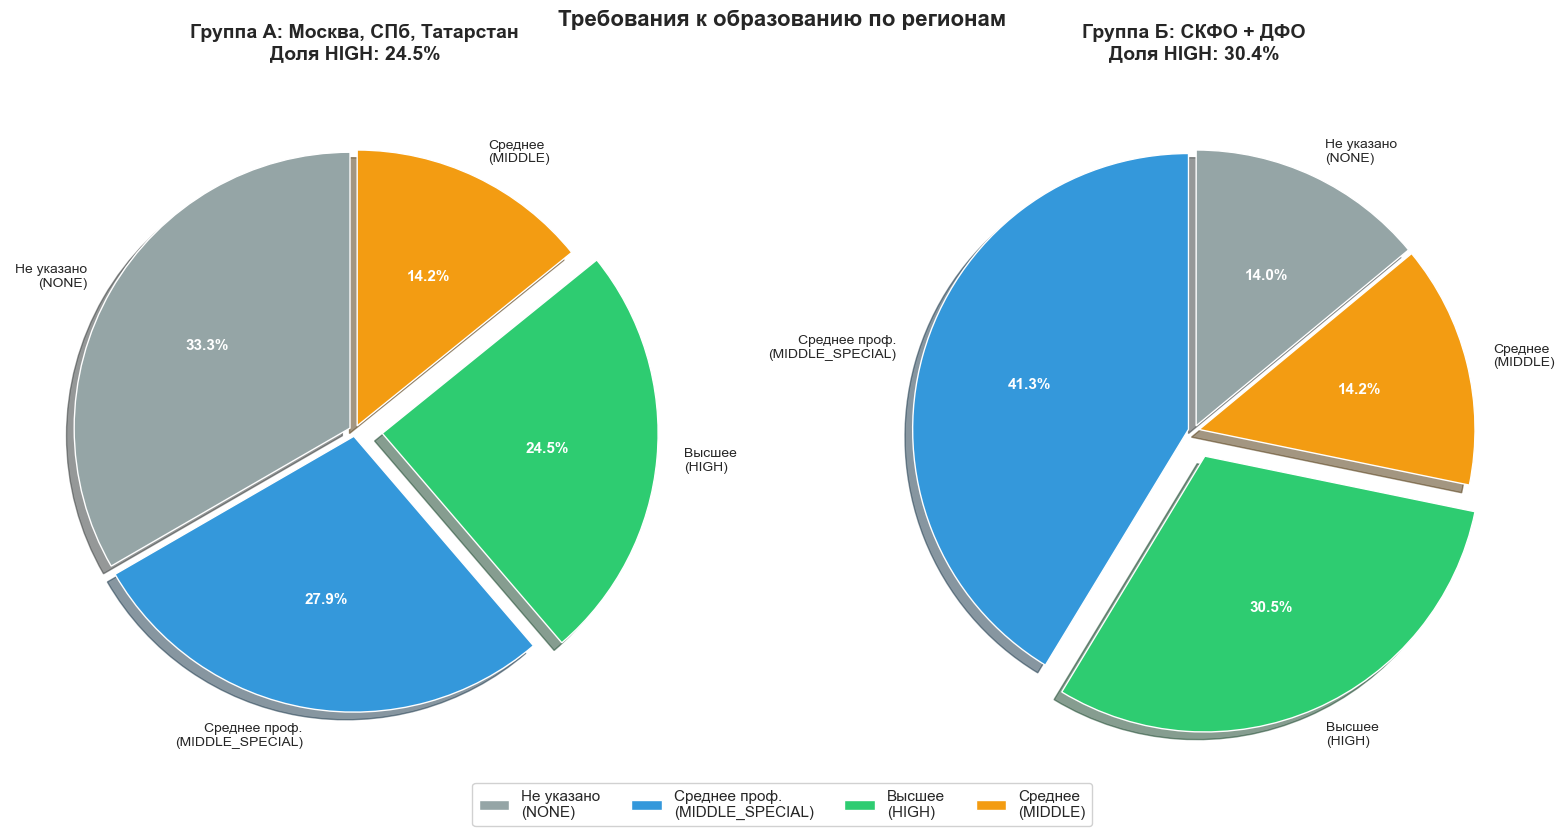

In [40]:
# Создание фигуры с двумя подграфиками (две круговые диаграммы)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Требования к образованию по регионам', fontsize=16, fontweight='bold')

# Цвета для категорий образования
colors = {
    'HIGH': '#2ecc71',           # Зелёный - высшее
    'MIDDLE_SPECIAL': '#3498db', # Синий - среднее проф.
    'MIDDLE': '#f39c12',         # Оранжевый - среднее
    'NONE': '#95a5a6'            # Серый - не указано
}

# Цвета для акцента на HIGH категории
highlight_colors = {
    'HIGH': '#27ae60',
    'MIDDLE_SPECIAL': '#bdc3c7',
    'MIDDLE': '#bdc3c7',
    'NONE': '#bdc3c7'
}

# Данные для каждой группы
for idx, group in enumerate(['GROUP_A', 'GROUP_B']):
    group_data = pie_data.filter(pl.col('region_group') == group).to_pandas()
    
    # Получаем процент HIGH для заголовка
    high_pct = group_data[group_data['education_category'] == 'HIGH']['percentage'].values
    high_pct = high_pct[0] if len(high_pct) > 0 else 0
    
    # Настройка заголовков
    titles = {
        'GROUP_A': 'Группа А: Москва, СПб, Татарстан',
        'GROUP_B': 'Группа Б: СКФО + ДФО'
    }
    
    # Построение круговой диаграммы
    wedges, texts, autotexts = axes[idx].pie(
        group_data['percentage'],
        labels=group_data['education_category'].map({
            'HIGH': 'Высшее\n(HIGH)',
            'MIDDLE_SPECIAL': 'Среднее проф.\n(MIDDLE_SPECIAL)',
            'MIDDLE': 'Среднее\n(MIDDLE)',
            'NONE': 'Не указано\n(NONE)'
        }),
        colors=[colors.get(cat, '#95a5a6') for cat in group_data['education_category']],
        autopct='%1.1f%%',
        startangle=90,
        explode=[0.1 if cat == 'HIGH' else 0.02 for cat in group_data['education_category']],  # Выделяем HIGH
        shadow=True
    )
    
    # Стилизация текста процентов
    for autotext in autotexts:
        autotext.set_fontsize(11)
        autotext.set_fontweight('bold')
        autotext.set_color('white')
    
    # Стилизация подписей категорий
    for text in texts:
        text.set_fontsize(10)
    
    # Заголовок с процентом HIGH
    axes[idx].set_title(
        f'{titles[group]}\nДоля HIGH: {high_pct:.1f}%',
        fontsize=14,
        pad=20,
        fontweight='bold'
    )

# Добавление общей легенды
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=4,
    fontsize=11,
    frameon=True,
    framealpha=0.9
)

plt.tight_layout()
plt.show()

## H3: Зарплата на удаленке

Внутри профессиональных сфер Вакансии с типом занятости busyType REMOTE имеют медианную зарплату выше на 15–20% по сравнению с аналогичными вакансиями типа FULL внутри одной профессиональной сферы (codeProfessionalSphere)

### Очистка зарплатных данных

In [41]:
# Создаем копию датасета для работы с гипотезой H3
df_h3 = vacancies_df.clone()

# Создаем колонку с медианной зарплатой (середина вилки)
df_h3 = df_h3.with_columns(
    pl.when(
        (pl.col('salaryMax').is_null()) | 
        (pl.col('salaryMax') == pl.col('salaryMin')) |
        (pl.col('salaryMax') <= 0)
    )
    .then(pl.col('salaryMin'))
    .otherwise((pl.col('salaryMin') + pl.col('salaryMax')) / 2)
    .alias('salary_median')
)

# Фильтрация некорректных зарплат
df_h3 = df_h3.filter(
    (pl.col('salary_median') >= 1000) & 
    (pl.col('salary_median') <= 1_000_000)
)

# Удаляем строки где salaryMin всё ещё null
df_h3 = df_h3.filter(pl.col('salaryMin').is_not_null())

In [42]:
print(f"Записей после очистки зарплат: {df_h3.height:,}")
print(f"Потеряно записей: {vacancies_df.height - df_h3.height:,}")

salary_stats = df_h3.select([
    pl.col('salary_median').min().alias('min'),
    pl.col('salary_median').max().alias('max'),
    pl.col('salary_median').median().alias('median'),
    pl.col('salary_median').mean().alias('mean')
])

print(salary_stats)

Записей после очистки зарплат: 443,584
Потеряно записей: 8,922
shape: (1, 4)
┌────────┬───────────┬─────────┬──────────────┐
│ min    ┆ max       ┆ median  ┆ mean         │
│ ---    ┆ ---       ┆ ---     ┆ ---          │
│ f32    ┆ f32       ┆ f32     ┆ f32          │
╞════════╪═══════════╪═════════╪══════════════╡
│ 1000.0 ┆ 9.99999e5 ┆ 46000.0 ┆ 54863.621094 │
└────────┴───────────┴─────────┴──────────────┘


### Фильтрация по типу занятости

In [43]:
df_h3['busyType'].value_counts(sort=True)

busyType,count
cat,u32
"""Полная занятость""",354582
null,66533
"""Временная""",13919
"""Частичная занятость""",4291
"""Сезонная""",2474
"""Стажировка""",907
"""Удалённая""",878


In [44]:
df_h3 = df_h3.filter(pl.col('busyType').cast(pl.String).str.contains('Полная занятость|Удалённая'))

df_h3 = df_h3.with_columns(
    pl.when(pl.col('busyType').cast(pl.String).str.to_uppercase() == 'ПОЛНАЯ ЗАНЯТОСТЬ')
    .then(pl.lit('FULL'))
    .when(pl.col('busyType').cast(pl.String).str.to_uppercase() == 'УДАЛЁННАЯ')
    .then(pl.lit('REMOTE'))
    .otherwise(pl.col('busyType').cast(pl.String))
    .alias('busyType')
)

In [45]:
df_h3['busyType'].value_counts(sort=True)

busyType,count
str,u32
"""FULL""",354582
"""REMOTE""",878


### Группировка по профессиональным сферам

In [46]:
print(f"Всего записей: {df_h3.height:,}")
print(f"Записей с null: {df_h3['codeProfessionalSphere'].null_count():,}")
print(f"Уникальных сфер: {df_h3['codeProfessionalSphere'].n_unique()}")

Всего записей: 355,460
Записей с null: 20
Уникальных сфер: 36


In [47]:
# Шаг 3.2: Если codeProfessionalSphere имеет пропуски, используем professionalSphereName
df_h3 = df_h3.with_columns(
    pl.when(pl.col('codeProfessionalSphere').is_null())
    .then(pl.col('professionalSphereName'))
    .otherwise(pl.col('codeProfessionalSphere'))
    .alias('sphere_id')
)

# Шаг 3.3: Группировка по сферам и подсчёт количества вакансий
sphere_stats = (
    df_h3
    .group_by('sphere_id')
    .agg(
        pl.len().alias('total_vacancies'),
        pl.col('busyType')
            .filter(pl.col('busyType') == 'REMOTE')
            .len()
            .alias('remote_count'),
        pl.col('busyType')
            .filter(pl.col('busyType') == 'FULL')
            .len()
            .alias('full_count')
    )
    .with_columns(
        (pl.col('remote_count') / pl.col('total_vacancies') * 100).round(2).alias('remote_percentage')
    )
    .sort('total_vacancies', descending=True)
)

In [48]:
print(sphere_stats)

shape: (36, 5)
┌───────────────────────────┬─────────────────┬──────────────┬────────────┬───────────────────┐
│ sphere_id                 ┆ total_vacancies ┆ remote_count ┆ full_count ┆ remote_percentage │
│ ---                       ┆ ---             ┆ ---          ┆ ---        ┆ ---               │
│ str                       ┆ u32             ┆ u32          ┆ u32        ┆ f64               │
╞═══════════════════════════╪═════════════════╪══════════════╪════════════╪═══════════════════╡
│ Medicine                  ┆ 62069           ┆ 23           ┆ 62046      ┆ 0.04              │
│ Education                 ┆ 54697           ┆ 51           ┆ 54646      ┆ 0.09              │
│ Industry                  ┆ 32855           ┆ 16           ┆ 32839      ┆ 0.05              │
│ Communal                  ┆ 22873           ┆ 13           ┆ 22860      ┆ 0.06              │
│ Agricultural              ┆ 14929           ┆ 0            ┆ 14929      ┆ 0.0               │
│ Sales                  

### Расчет метрик

In [49]:
# Расчет медианной зарплаты для каждой комбинации
sphere_salary_median = (
    df_h3
    .group_by('sphere_id', 'busyType')
    .agg(
        pl.col('salary_median').median().alias('median_salary'),
        pl.len().alias('vacancy_count')
    )
    .filter(
        (pl.col('vacancy_count') >= 10)  # Минимум 10 вакансий для устойчивости статистики
    )
)

In [50]:
print(sphere_salary_median.head(20))

shape: (20, 4)
┌───────────────────────────┬──────────┬───────────────┬───────────────┐
│ sphere_id                 ┆ busyType ┆ median_salary ┆ vacancy_count │
│ ---                       ┆ ---      ┆ ---           ┆ ---           │
│ str                       ┆ str      ┆ f32           ┆ u32           │
╞═══════════════════════════╪══════════╪═══════════════╪═══════════════╡
│ NotQualification          ┆ FULL     ┆ 32500.0       ┆ 6850          │
│ Marketing                 ┆ FULL     ┆ 45000.0       ┆ 317           │
│ Safety                    ┆ REMOTE   ┆ 50000.0       ┆ 40            │
│ HomePersonal              ┆ FULL     ┆ 37500.0       ┆ 177           │
│ Consulting                ┆ FULL     ┆ 41745.0       ┆ 645           │
│ Metallurgy                ┆ FULL     ┆ 66000.0       ┆ 3343          │
│ HumanRecruitment          ┆ REMOTE   ┆ 97500.0       ┆ 16            │
│ Communal                  ┆ FULL     ┆ 43000.0       ┆ 22860         │
│ Communal                  ┆ REMOTE

In [51]:
# Разворачиваем таблицу: REMOTE и FULL становятся отдельными колонками
salary_pivot = (
    sphere_salary_median
    .pivot(
        index='sphere_id',
        columns='busyType',
        values='median_salary',
        aggregate_function='first'
    )
)

# Переименовываем колонки для удобства
salary_pivot = salary_pivot.rename({
    'REMOTE': 'median_remote',
    'FULL': 'median_full'
})

# Расчет процентной разницы: (REMOTE - FULL) / FULL * 100
salary_pivot = salary_pivot.with_columns(
    pl.when(pl.col('median_full') > 0)
    .then((pl.col('median_remote') - pl.col('median_full')) / pl.col('median_full') * 100)
    .otherwise(None)
    .round(2)
    .alias('diff_percentage')
)

# Добавляем количество вакансий для каждой группы (для фильтрации)
vacancy_counts = (
    sphere_salary_median
    .group_by('sphere_id')
    .agg(
        pl.col('vacancy_count').sum().alias('total_vacancies'),
        pl.col('vacancy_count')
            .filter(pl.col('busyType') == 'REMOTE')
            .sum()
            .alias('remote_vacancies'),
        pl.col('vacancy_count')
            .filter(pl.col('busyType') == 'FULL')
            .sum()
            .alias('full_vacancies')
    )
)

# Объединяем с данными о разницах
salary_diff = salary_pivot.join(vacancy_counts, on='sphere_id', how='inner')

# Фильтруем сферы где есть оба типа занятости (и REMOTE, и FULL)
salary_diff = salary_diff.filter(
    (pl.col('median_remote').is_not_null()) & 
    (pl.col('median_full').is_not_null())
)

C:\Users\Qd\AppData\Local\Temp\ipykernel_16140\1281172340.py:4: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  .pivot(


In [52]:
print(salary_diff.select([
    'sphere_id', 'median_remote', 'median_full', 'diff_percentage', 
    'remote_vacancies', 'full_vacancies'
]).sort('diff_percentage', descending=True).head(20))

shape: (17, 6)
┌───────────────────────────┬───────────────┬─────────────┬─────────────────┬──────────────────┬────────────────┐
│ sphere_id                 ┆ median_remote ┆ median_full ┆ diff_percentage ┆ remote_vacancies ┆ full_vacancies │
│ ---                       ┆ ---           ┆ ---         ┆ ---             ┆ ---              ┆ ---            │
│ str                       ┆ f32           ┆ f32         ┆ f32             ┆ u32              ┆ u32            │
╞═══════════════════════════╪═══════════════╪═════════════╪═════════════════╪══════════════════╪════════════════╡
│ HumanRecruitment          ┆ 97500.0       ┆ 42500.0     ┆ 129.410004      ┆ 16               ┆ 748            │
│ StateServices             ┆ 85000.0       ┆ 46316.75    ┆ 83.519997       ┆ 62               ┆ 11844          │
│ Management                ┆ 125000.0      ┆ 75000.0     ┆ 66.669998       ┆ 85               ┆ 308            │
│ NotQualification          ┆ 52500.0       ┆ 32500.0     ┆ 61.540001    

In [53]:
# Общая медиана по всем REMOTE вакансиям
overall_remote_median = df_h3.filter(
    pl.col('busyType') == 'REMOTE'
)['salary_median'].median()

# Общая медиана по всем FULL вакансиям
overall_full_median = df_h3.filter(
    pl.col('busyType') == 'FULL'
)['salary_median'].median()

# Общая процентная разница
overall_diff_percentage = (overall_remote_median - overall_full_median) / overall_full_median * 100

print(f"Медианная зарплата REMOTE: {overall_remote_median:,.0f} руб.")
print(f"Медианная зарплата FULL:   {overall_full_median:,.0f} руб.")
print(f"Общая разница:              {overall_diff_percentage:+.2f}%")

Медианная зарплата REMOTE: 52,500 руб.
Медианная зарплата FULL:   45,000 руб.
Общая разница:              +16.67%


In [54]:
# Статистика по разнице в разрезе сфер
diff_stats = salary_diff.select([
    pl.col('diff_percentage').median().alias('median_diff'),
    pl.col('diff_percentage').mean().alias('mean_diff'),
    pl.col('diff_percentage').min().alias('min_diff'),
    pl.col('diff_percentage').max().alias('max_diff'),
    pl.col('diff_percentage').std().alias('std_diff')
])

print(diff_stats)

shape: (1, 5)
┌─────────────┬───────────┬────────────┬────────────┬───────────┐
│ median_diff ┆ mean_diff ┆ min_diff   ┆ max_diff   ┆ std_diff  │
│ ---         ┆ ---       ┆ ---        ┆ ---        ┆ ---       │
│ f32         ┆ f32       ┆ f32        ┆ f32        ┆ f32       │
╞═════════════╪═══════════╪════════════╪════════════╪═══════════╡
│ 31.940001   ┆ 32.158825 ┆ -54.849998 ┆ 129.410004 ┆ 41.051468 │
└─────────────┴───────────┴────────────┴────────────┴───────────┘


In [55]:
spheres_higher = salary_diff.filter(pl.col('diff_percentage') > 0).height
spheres_lower = salary_diff.filter(pl.col('diff_percentage') < 0).height
total_spheres = salary_diff.height

print(f"REMOTE платят больше: {spheres_higher} из {total_spheres} ({spheres_higher/total_spheres*100:.1f}%)")

REMOTE платят больше: 15 из 17 (88.2%)


In [56]:
# Условие гипотезы: разница 15-20% в пользу REMOTE
h3_threshold_min = 15.0
h3_threshold_max = 20.0

# Проверка по общей медиане
h3_confirmed_overall = (overall_diff_percentage >= h3_threshold_min) & (overall_diff_percentage <= h3_threshold_max + 5)  # +5% допуск

# Проверка по медиане разницы по сферам
median_diff_value = diff_stats['median_diff'][0]
h3_confirmed_spheres = (median_diff_value >= h3_threshold_min) & (median_diff_value <= h3_threshold_max + 5)

In [57]:
print(f"Порог гипотезы: {h3_threshold_min}% - {h3_threshold_max}%")
print(f"Общая разница (REMOTE vs FULL): {overall_diff_percentage:+.2f}%")
print(f"Медианная разница по сферам: {median_diff_value:+.2f}%")

Порог гипотезы: 15.0% - 20.0%
Общая разница (REMOTE vs FULL): +16.67%
Медианная разница по сферам: +31.94%


In [58]:
h3_results = {
    'overall_remote_median': round(overall_remote_median, 2),
    'overall_full_median': round(overall_full_median, 2),
    'overall_diff_percentage': round(overall_diff_percentage, 2),
    'median_diff_by_sphere': round(median_diff_value, 2),
    'threshold_min': h3_threshold_min,
    'threshold_max': h3_threshold_max,
    'confirmed': bool(h3_confirmed_overall or h3_confirmed_spheres),
    'total_spheres': total_spheres,
    'spheres_higher': spheres_higher,
    'spheres_lower': spheres_lower
}

## H4: Компенсация удаленности предоставлением жилья

Регионы с низким количеством активных компаний (Север, Дальний Восток) имеют значительно более высокую долю вакансий с флагом предоставления жилья (`accommodationCapability=true`), используя этот бонус для привлечения кадров в условиях географической изоляции.

In [59]:
vacancies_df['accommodationCapability'].value_counts(sort=True)

accommodationCapability,count
bool,u32
false,437974
true,14532


### Определение «удаленных» регионов и классификация

In [60]:
# Создаем копию датасета для работы с гипотезой H4
df_h4 = vacancies_df.clone()

# Код федерального округа для ДФО (Дальневосточный) = 8
# Также добавим северные регионы через список названий
DFO_CODE = 8

# Список регионов Севера и Дальнего Востока (по названию из датасета)
NORTHERN_REGIONS = [
    # Дальневосточный федеральный округ
    "Республика Саха (Якутия)",
    "Камчатский край",
    "Приморский край",
    "Хабаровский край",
    "Амурская область",
    "Магаданская область",
    "Сахалинская область",
    "Еврейская автономная область",
    "Чукотский автономный округ",
    # Северные регионы других округов
    "Мурманская область",
    "Архангельская область",
    "Ненецкий автономный округ",
    "Ямало-Ненецкий автономный округ",
    "Ханты-Мансийский автономный округ",
    "Республика Коми",
    "Красноярский край",
    "Иркутская область",
    "Республика Бурятия",
    "Забайкальский край",
]

# Функция для классификации региона
def classify_region_for_h4(region_name: str, federal_district_code: int) -> str:
    """
    Классифицирует регион на группу для гипотезы H4.
    
    Возвращает:
    - 'REMOTE': Удаленные регионы (Север, ДФО)
    - 'OTHER': Все остальные регионы
    """
    # Проверка по списку названий
    if region_name in NORTHERN_REGIONS:
        return 'REMOTE'
    
    # Проверка по коду федерального округа (ДФО = 8)
    if federal_district_code == DFO_CODE:
        return 'REMOTE'
    
    return 'OTHER'

# Применяем классификацию к датасету
df_h4 = df_h4.with_columns(
    pl.struct(['regionName', 'federalDistrictCode'])
    .map_elements(
        lambda x: classify_region_for_h4(x['regionName'], x['federalDistrictCode']),
        return_dtype=pl.Categorical
    )
    .alias('region_type')
)

# Проверка распределения по группам
region_distribution = (
    df_h4
    .group_by('region_type')
    .agg(pl.len().alias('vacancy_count'))
    .with_columns(
        (pl.col('vacancy_count') / pl.col('vacancy_count').sum() * 100).round(2).alias('percentage')
    )
    .sort('vacancy_count', descending=True)
)

print("Распределение вакансий по типам регионов:")
print(region_distribution)

Распределение вакансий по типам регионов:
shape: (2, 3)
┌─────────────┬───────────────┬────────────┐
│ region_type ┆ vacancy_count ┆ percentage │
│ ---         ┆ ---           ┆ ---        │
│ cat         ┆ u32           ┆ f64        │
╞═════════════╪═══════════════╪════════════╡
│ OTHER       ┆ 365647        ┆ 80.8       │
│ REMOTE      ┆ 86859         ┆ 19.2       │
└─────────────┴───────────────┴────────────┘


### Детализация по регионам внутри группы REMOTE (валидация)

In [61]:
# Проверка состава группы REMOTE (какие регионы попали)
remote_regions_check = (
    df_h4
    .filter(pl.col('region_type') == 'REMOTE')
    .group_by('regionName')
    .agg(
        pl.len().alias('vacancy_count'),
        pl.col('accommodationCapability')
            .filter(pl.col('accommodationCapability') == True)
            .count()
            .alias('with_housing_count')
    )
    .with_columns(
        (pl.col('with_housing_count') / pl.col('vacancy_count') * 100).round(2).alias('housing_percentage')
    )
    .sort('vacancy_count', descending=True)
)

print("\nСостав группы REMOTE (топ-20 регионов по количеству вакансий):")
print(remote_regions_check.head(20))

# Проверка уникальных регионов в группе REMOTE
print(f"\nВсего уникальных регионов в группе REMOTE: {remote_regions_check.height}")


Состав группы REMOTE (топ-20 регионов по количеству вакансий):
shape: (20, 4)
┌─────────────────────────────────┬───────────────┬────────────────────┬────────────────────┐
│ regionName                      ┆ vacancy_count ┆ with_housing_count ┆ housing_percentage │
│ ---                             ┆ ---           ┆ ---                ┆ ---                │
│ str                             ┆ u32           ┆ u32                ┆ f64                │
╞═════════════════════════════════╪═══════════════╪════════════════════╪════════════════════╡
│ Красноярский край               ┆ 11072         ┆ 399                ┆ 3.6                │
│ Приморский край                 ┆ 9763          ┆ 603                ┆ 6.18               │
│ Иркутская область               ┆ 9754          ┆ 274                ┆ 2.81               │
│ Ставропольский край             ┆ 9173          ┆ 78                 ┆ 0.85               │
│ Хабаровский край                ┆ 6547          ┆ 248                ┆ 3.

###  Расчет метрики активности компаний по регионам

In [62]:
vacancies_df.select(cs.contains("company"))[:5]

company,companyBusinessSize
str,cat
"""{""companyCode"": ""d4004160-74c4-11ea-ace8-e37b4be0b…","""LARGE"""
"""{""companyCode"": ""d4004160-74c4-11ea-ace8-e37b4be0b…","""LARGE"""
"""{""companyCode"": ""7226c750-02f1-11eb-8600-bfd133996…","""SMALL"""
"""{""companyCode"": ""7226c750-02f1-11eb-8600-bfd133996…","""SMALL"""
"""{""companyCode"": ""d4004160-74c4-11ea-ace8-e37b4be0b…","""LARGE"""


In [63]:
vacancies_df["company"][0]

'{"companyCode": "d4004160-74c4-11ea-ace8-e37b4be0b9ed", "url": "https://trudvsem.ru/company/d4004160-74c4-11ea-ace8-e37b4be0b9ed", "inn": "7204006910", "email": "medgorod@med-to.ru", "kpp": "720301001", "ogrn": "1037200556117", "site": "https://medgorod.info/"}'

In [64]:
# Функция для извлечения companyCode из JSON-строки
def extract_company_code(json_str: Optional[str]) -> Optional[str]:
    """
    Извлекает companyCode из JSON-строки поля company.
    Возвращает None если строка пуста, null или невалидный JSON.
    """
    if json_str is None or json_str == '' or json_str == 'null':
        return None
    
    try:
        data = json.loads(json_str.strip())
        if isinstance(data, dict):
            # Пробуем companyCode, если нет — используем inn как резервный идентификатор
            code = data.get('companyCode', None)
            if code is None:
                code = data.get('inn', None)
            return code
        return None
    except (json.JSONDecodeError, TypeError, AttributeError):
        return None

# Шаг 3.1: Парсим поле company и извлекаем companyCode
df_h4 = df_h4.with_columns(
    pl.col('company')
    .map_elements(extract_company_code, return_dtype=pl.String)
    .alias('company_code_extracted')
)

# Проверка результата
print("Пример извлеченных companyCode:")
print(df_h4.select(['company', 'company_code_extracted']).head(5))

# Шаг 3.2: Фильтруем записи где не удалось извлечь companyCode
df_h4_with_company = df_h4.filter(pl.col('company_code_extracted').is_not_null())

print(f"\nЗаписей с companyCode: {df_h4_with_company.height:,} из {df_h4.height:,}")
print(f"Потеряно записей: {df_h4.height - df_h4_with_company.height:,}")

# Шаг 3.3: Расчет количества уникальных компаний в каждом регионе
company_activity_by_region = (
    df_h4_with_company
    .group_by('regionName', 'region_type')
    .agg(
        pl.col('company_code_extracted').n_unique().alias('unique_companies'),
        pl.len().alias('total_vacancies')
    )
    .with_columns(
        (pl.col('total_vacancies') / pl.col('unique_companies')).round(2).alias('vacancies_per_company')
    )
    .sort('unique_companies', descending=True)
)

print("\nАктивность компаний по регионам (топ-20):")
print(company_activity_by_region.head(20))

# Шаг 3.4: Сравнение активности между группами REMOTE и OTHER
company_activity_summary = (
    company_activity_by_region
    .group_by('region_type')
    .agg(
        pl.col('unique_companies').sum().alias('total_unique_companies'),
        pl.col('total_vacancies').sum().alias('total_vacancies'),
        pl.col('vacancies_per_company').median().alias('median_vacancies_per_company'),
        pl.col('vacancies_per_company').mean().alias('mean_vacancies_per_company')
    )
)

print("\nСравнение активности компаний по группам регионов:")
print(company_activity_summary)

# Шаг 3.5: Проверка предпосылки гипотезы
remote_companies = company_activity_summary.filter(
    pl.col('region_type') == 'REMOTE'
)['total_unique_companies'][0]

other_companies = company_activity_summary.filter(
    pl.col('region_type') == 'OTHER'
)['total_unique_companies'][0]

print(f"\nПредпосылка гипотезы:")
print(f"  Удаленные регионы (REMOTE): {remote_companies:,} уникальных компаний")
print(f"  Остальные регионы (OTHER): {other_companies:,} уникальных компаний")
print(f"  Соотношение: {remote_companies / other_companies * 100:.2f}%")

if remote_companies < other_companies:
    print("  ✅ Предпосылка подтверждается: в удаленных регионах меньше компаний")
else:
    print("  ⚠️ Предпосылка не подтверждается")

Пример извлеченных companyCode:
shape: (5, 2)
┌─────────────────────────────────────────────────────┬──────────────────────────────────────┐
│ company                                             ┆ company_code_extracted               │
│ ---                                                 ┆ ---                                  │
│ str                                                 ┆ str                                  │
╞═════════════════════════════════════════════════════╪══════════════════════════════════════╡
│ {"companyCode": "d4004160-74c4-11ea-ace8-e37b4be0b… ┆ d4004160-74c4-11ea-ace8-e37b4be0b9ed │
│ {"companyCode": "d4004160-74c4-11ea-ace8-e37b4be0b… ┆ d4004160-74c4-11ea-ace8-e37b4be0b9ed │
│ {"companyCode": "7226c750-02f1-11eb-8600-bfd133996… ┆ 7226c750-02f1-11eb-8600-bfd13399602c │
│ {"companyCode": "7226c750-02f1-11eb-8600-bfd133996… ┆ 7226c750-02f1-11eb-8600-bfd13399602c │
│ {"companyCode": "d4004160-74c4-11ea-ace8-e37b4be0b… ┆ d4004160-74c4-11ea-ace8-e37b4be0b9ed │
└───

In [65]:
print(f"Всего записей: {df_h4.height:,}")
print(f"Группа REMOTE (Север, ДФО): {df_h4.filter(pl.col('region_type') == 'REMOTE').height:,} вакансий")
print(f"Группа OTHER (остальные): {df_h4.filter(pl.col('region_type') == 'OTHER').height:,} вакансий")

# Проверка поля accommodationCapability
print(f"\nСтатистика по accommodationCapability:")
print(df_h4['accommodationCapability'].value_counts(sort=True))

Всего записей: 452,506
Группа REMOTE (Север, ДФО): 86,859 вакансий
Группа OTHER (остальные): 365,647 вакансий

Статистика по accommodationCapability:
shape: (2, 2)
┌─────────────────────────┬────────┐
│ accommodationCapability ┆ count  │
│ ---                     ┆ ---    │
│ bool                    ┆ u32    │
╞═════════════════════════╪════════╡
│ false                   ┆ 437974 │
│ true                    ┆ 14532  │
└─────────────────────────┴────────┘


### Расчет доли вакансий с жильем по группам регионов

In [66]:
# Настройка стилей для графиков
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

# Проверка наличия данных
print(f"Всего записей в df_h4: {df_h4.height:,}")
print(f"Записей с accommodationCapability=True: {df_h4.filter(pl.col('accommodationCapability') == True).height:,}")

# Группировка по типу региона и расчет доли вакансий с жильем
housing_by_region = (
    df_h4
    .group_by('region_type')
    .agg(
        pl.len().alias('total_vacancies'),
        pl.col('accommodationCapability')
            .filter(pl.col('accommodationCapability') == True)
            .count()
            .alias('with_housing_count')
    )
    .with_columns(
        (pl.col('with_housing_count') / pl.col('total_vacancies') * 100).round(2).alias('housing_percentage')
    )
    .sort('region_type')
)

print("\nДоля вакансий с предоставлением жилья по группам регионов:")
print(housing_by_region)

Всего записей в df_h4: 452,506
Записей с accommodationCapability=True: 14,532

Доля вакансий с предоставлением жилья по группам регионов:
shape: (2, 4)
┌─────────────┬─────────────────┬────────────────────┬────────────────────┐
│ region_type ┆ total_vacancies ┆ with_housing_count ┆ housing_percentage │
│ ---         ┆ ---             ┆ ---                ┆ ---                │
│ cat         ┆ u32             ┆ u32                ┆ f64                │
╞═════════════╪═════════════════╪════════════════════╪════════════════════╡
│ OTHER       ┆ 365647          ┆ 10832              ┆ 2.96               │
│ REMOTE      ┆ 86859           ┆ 3700               ┆ 4.26               │
└─────────────┴─────────────────┴────────────────────┴────────────────────┘


In [67]:
remote_data = dict(zip(
    housing_by_region.columns, 
    housing_by_region.filter(pl.col('region_type') == 'REMOTE').row(0)
))
other_data = dict(zip(
    housing_by_region.columns, 
    housing_by_region.filter(pl.col('region_type') == 'OTHER').row(0)
))


remote_percentage = remote_data['housing_percentage']
other_percentage = other_data['housing_percentage']

# Расчет разницы в процентных пунктах
percentage_diff = remote_percentage - other_percentage

# Расчет отношения долей (во сколько раз больше в удаленных регионах)
ratio = remote_percentage / other_percentage if other_percentage > 0 else float('inf')

print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ ПРОВЕРКИ ГИПОТЕЗЫ H4")
print("="*70)
print(f"\nГруппа REMOTE (Север, ДФО):")
print(f"  - Всего вакансий: {remote_data['total_vacancies']:,}")
print(f"  - С предоставлением жилья: {remote_data['with_housing_count']:,}")
print(f"  - Доля с жильем: {remote_percentage:.2f}%")

print(f"\nГруппа OTHER (остальные регионы):")
print(f"  - Всего вакансий: {other_data['total_vacancies']:,}")
print(f"  - С предоставлением жилья: {other_data['with_housing_count']:,}")
print(f"  - Доля с жильем: {other_percentage:.2f}%")

print(f"\nРазница (REMOTE - OTHER): {percentage_diff:.2f} п.п.")
print(f"Отношение долей (REMOTE / OTHER): {ratio:.2f} раз")

# Проверка условия гипотезы
# Гипотеза подтверждается если доля в удаленных регионах значительно выше
h4_threshold_diff = 5.0  # Минимальная разница в процентных пунктах
h4_threshold_ratio = 2.0  # Минимальное отношение долей

h4_confirmed_diff = percentage_diff >= h4_threshold_diff
h4_confirmed_ratio = ratio >= h4_threshold_ratio

print("\n" + "-"*70)
if h4_confirmed_diff or h4_confirmed_ratio:
    print("✅ ГИПОТЕЗА H4 ПОДТВЕРЖДЕНА")
    if h4_confirmed_diff:
        print(f"   Разница {percentage_diff:.2f}% ≥ порога {h4_threshold_diff}%")
    if h4_confirmed_ratio:
        print(f"   Отношение {ratio:.2f}x ≥ порога {h4_threshold_ratio}x")
else:
    print("❌ ГИПОТЕЗА H4 ОПРОВЕРГНУТА")
    print(f"   Разница {percentage_diff:.2f}% < порога {h4_threshold_diff}%")
    print(f"   Отношение {ratio:.2f}x < порога {h4_threshold_ratio}x")
print("-"*70)


РЕЗУЛЬТАТЫ ПРОВЕРКИ ГИПОТЕЗЫ H4

Группа REMOTE (Север, ДФО):
  - Всего вакансий: 86,859
  - С предоставлением жилья: 3,700
  - Доля с жильем: 4.26%

Группа OTHER (остальные регионы):
  - Всего вакансий: 365,647
  - С предоставлением жилья: 10,832
  - Доля с жильем: 2.96%

Разница (REMOTE - OTHER): 1.30 п.п.
Отношение долей (REMOTE / OTHER): 1.44 раз

----------------------------------------------------------------------
❌ ГИПОТЕЗА H4 ОПРОВЕРГНУТА
   Разница 1.30% < порога 5.0%
   Отношение 1.44x < порога 2.0x
----------------------------------------------------------------------


In [68]:
# Расчет доли вакансий с жильем по каждому региону
housing_by_region_detail = (
    df_h4
    .group_by('regionName', 'region_type')
    .agg(
        pl.len().alias('total_vacancies'),
        pl.col('accommodationCapability')
            .filter(pl.col('accommodationCapability') == True)
            .count()
            .alias('with_housing_count')
    )
    .with_columns(
        (pl.col('with_housing_count') / pl.col('total_vacancies') * 100).round(2).alias('housing_percentage')
    )
    .filter((pl.col('total_vacancies') >= 100) &
            (pl.col('regionName').is_not_null())
           )
    .sort('housing_percentage', descending=True)
)

print("Топ-15 регионов по доле вакансий с предоставлением жилья:")
print(housing_by_region_detail.head(15).to_pandas().to_string(index=False))

# Проверка сколько регионов из топ-15 относятся к REMOTE
top15_remote_count = housing_by_region_detail.head(15).filter(
    pl.col('region_type') == 'REMOTE'
).height

print(f"\nИз топ-15 регионов к группе REMOTE относятся: {top15_remote_count} ({top15_remote_count/15*100:.1f}%)")

Топ-15 регионов по доле вакансий с предоставлением жилья:
                     regionName region_type  total_vacancies  with_housing_count  housing_percentage
     Чукотский автономный округ      REMOTE              564                  74               13.12
               Амурская область      REMOTE             3251                 396               12.18
  Сириус федеральная территория       OTHER              103                   9                8.74
          Ленинградская область       OTHER             8893                 742                8.34
Ямало-Ненецкий автономный округ      REMOTE             3432                 264                7.69
              Рязанская область       OTHER             3643                 275                7.55
             Забайкальский край      REMOTE             5001                 317                6.34
       Республика Саха (Якутия)      REMOTE             3493                 220                6.30
                Приморский край  

In [69]:
housing_by_region_detail

regionName,region_type,total_vacancies,with_housing_count,housing_percentage
str,cat,u32,u32,f64
"""Чукотский автономный округ""","""REMOTE""",564,74,13.12
"""Амурская область""","""REMOTE""",3251,396,12.18
"""Сириус федеральная территория""","""OTHER""",103,9,8.74
"""Ленинградская область""","""OTHER""",8893,742,8.34
"""Ямало-Ненецкий автономный округ""","""REMOTE""",3432,264,7.69
"""Рязанская область""","""OTHER""",3643,275,7.55
"""Забайкальский край""","""REMOTE""",5001,317,6.34
"""Республика Саха (Якутия)""","""REMOTE""",3493,220,6.3
"""Приморский край""","""REMOTE""",9763,603,6.18


### Визуализация

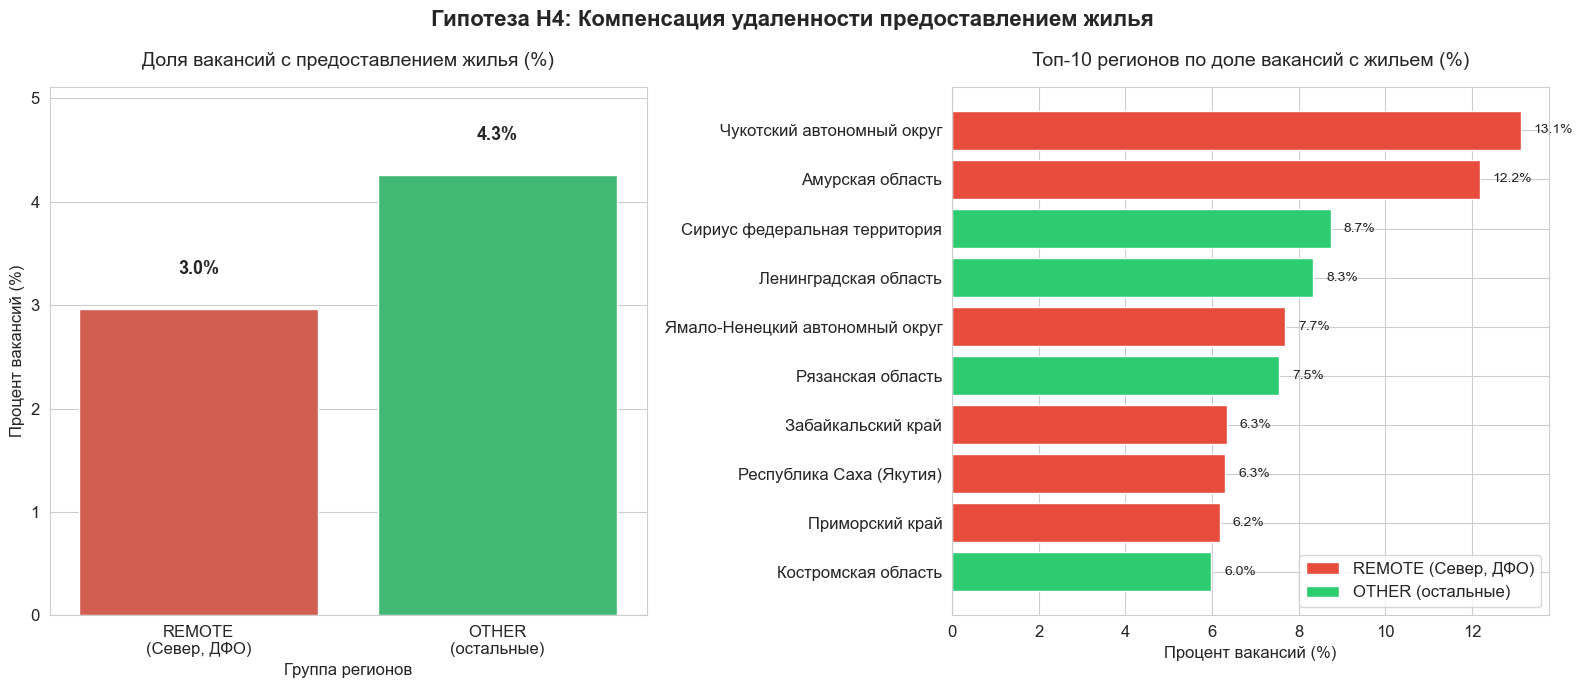

In [70]:
# Создание фигуры с двумя подграфиками
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Гипотеза H4: Компенсация удаленности предоставлением жилья', fontsize=16, fontweight='bold')

# График 1: Столбчатая диаграмма доли вакансий с жильем по группам
ax1 = axes[0]
plot_data = housing_by_region.to_pandas()

bars = sns.barplot(
    data=plot_data,
    x='region_type',
    y='housing_percentage',
    hue='region_type',
    palette=['#e74c3c', '#2ecc71'],
    ax=ax1
)

# Добавление подписей значений на столбцы
for bar in bars.patches:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2.,
        height + 0.3,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=13,
        fontweight='bold'
    )

ax1.set_title('Доля вакансий с предоставлением жилья (%)', fontsize=14, pad=15)
ax1.set_xlabel('Группа регионов', fontsize=12)
ax1.set_ylabel('Процент вакансий (%)', fontsize=12)
ax1.set_ylim(0, max(plot_data['housing_percentage']) * 1.2)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['REMOTE\n(Север, ДФО)', 'OTHER\n(остальные)'], rotation=0)

# График 2: Топ-10 регионов по доле вакансий с жильем
ax2 = axes[1]
top10_data = housing_by_region_detail.head(10).to_pandas()

# Цвета для регионов REMOTE и OTHER
colors = ['#e74c3c' if t == 'REMOTE' else '#2ecc71' for t in top10_data['region_type']]

bars2 = ax2.barh(top10_data['regionName'], top10_data['housing_percentage'], color=colors)

# Добавление подписей значений
for bar, val in zip(bars2, top10_data['housing_percentage']):
    ax2.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=10)

ax2.set_title('Топ-10 регионов по доле вакансий с жильем (%)', fontsize=14, pad=15)
ax2.set_xlabel('Процент вакансий (%)', fontsize=12)
ax2.invert_yaxis()  # Чтобы первый регион был сверху

# Легенда
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='REMOTE (Север, ДФО)'),
    Patch(facecolor='#2ecc71', label='OTHER (остальные)')
]
ax2.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

# **КОРРЕЛЯЦИОННЫЙ АНАЛИЗ**

In [41]:
# Шаг 2.1: Создаем копию исходного датафрейма для работы
corr_df = vacancies_df.clone()

print(f"Исходное количество колонок: {corr_df.width}")
print(f"Исходное количество строк: {corr_df.height:,}")

Исходное количество колонок: 80
Исходное количество строк: 452,506


In [66]:
# 1. Замена '[]' и '{}' на null
string_columns = [col for col in corr_df.columns if corr_df[col].dtype == pl.String]

if string_columns:
    corr_df = corr_df.with_columns(
        [
            pl.col(col).replace(['[]', '{}'], None).alias(col)
            for col in string_columns
        ]
    )
else:
    print("Строковые колонки для замены не найдены.")

In [67]:
# Шаг 2.2: Рассчитываем процент пропусков для каждой колонки
null_stats = corr_df.select([
    pl.col(col).null_count().alias(col) for col in corr_df.columns
]).transpose(include_header=True, header_name="column")

null_stats = null_stats.with_columns(
    pl.col("column_0").cast(pl.Int64).alias("null_count"),
    ((pl.col("column_0") / corr_df.height) * 100).round(2).alias("null_percentage")
).select(["column", "null_count", "null_percentage"])

# Шаг 2.3: Определяем колонки для удаления (>68% пропусков)
columns_to_drop = null_stats.filter(
    pl.col("null_percentage") > 68.0
)["column"].to_list()

print(f"Колонки для удаления (>68% пропусков): {len(columns_to_drop)}")
print(columns_to_drop)

Колонки для удаления (>68% пропусков): 32
['vacancyAddressAdditionalInfo', 'socialProtecteds', 'languageKnowledge', 'hardSkills', 'softSkills', 'skills', 'premium', 'otherVacancyBenefit', 'codeExternalSystem', 'idPriorityCategory', 'requiredСertificates', 'requiredDriveLicense', 'retrainingCapability', 'retrainingСondition', 'retrainingGrantValue', 'transportCompensation', 'contactSource', 'oknpoCode', 'oksoCode', 'industryBranchName', 'accommodationType', 'metroIds', 'isMobilityProgram', 'additionalRequirements', 'addressOffice', 'hireDate', 'medicalCertificate', 'scheduleTypeComment', 'benefitDetails', 'shift', 'medicalDocument', 'benefit']


In [68]:
columns_to_drop2 = [
    # --- Константы и почти константы ---
    'visibility',           # 100% "Видно всем"
    'status',               # 100% "Одобрено"
    'isModerated',          # 100% True
    'deleted',              # 100% False
    'isUzbekistanRecruitment', # 99.95% False
    'trainingDays',         # 99% значений = 0 (почти константа)

    
    # --- Уникальные идентификаторы ---
    'id',                   # UUID вакансии
    'vacancyUrl',           # Ссылка на вакансию
    'positionRequirements', # 255k уникальных требований (текст)
    'responsibilities',     # 330k уникальных обязанностей (текст)

    # --- Дублирующая или избыточная информация ---
    'professionalSphereName', # Дублирует codeProfessionalSphere (текст vs код)
    'changeTime',           # Время изменения (дублирует дату модификации)
    'dateModify',           # Дата изменения (часто совпадает с publication)


]

columns_to_drop += columns_to_drop2

print(f"Колонки для удаления: {len(columns_to_drop)}")
print(columns_to_drop)

Колонки для удаления: 45
['vacancyAddressAdditionalInfo', 'socialProtecteds', 'languageKnowledge', 'hardSkills', 'softSkills', 'skills', 'premium', 'otherVacancyBenefit', 'codeExternalSystem', 'idPriorityCategory', 'requiredСertificates', 'requiredDriveLicense', 'retrainingCapability', 'retrainingСondition', 'retrainingGrantValue', 'transportCompensation', 'contactSource', 'oknpoCode', 'oksoCode', 'industryBranchName', 'accommodationType', 'metroIds', 'isMobilityProgram', 'additionalRequirements', 'addressOffice', 'hireDate', 'medicalCertificate', 'scheduleTypeComment', 'benefitDetails', 'shift', 'medicalDocument', 'benefit', 'visibility', 'status', 'isModerated', 'deleted', 'isUzbekistanRecruitment', 'trainingDays', 'id', 'vacancyUrl', 'positionRequirements', 'responsibilities', 'professionalSphereName', 'changeTime', 'dateModify']


In [74]:
# corr_df["needMedcard"][:10]

Может распрарсить:

'vacancyAddress',       # 175k уникальных адресов (есть regionName)
'vacancyAddressHouse',  # 30k уникальных номеров домов
'contactList',          # JSON со контактами (высокая кардинальность)
'company',              # JSON с данными компании (высокая кардинальность)
'workPlace',            # JSON с деталями рабочего места (сложная структура)
'geo',                  # JSON с координатами (высокая кардинальность), координаты как числовые признаки
'typicalPosition',      # 1k уникальных позиций (можно попробовать, но пока удалим для чистоты эксперимента)

Может в категории:

'addressCode',          # Код адреса (дублирует регион, большие числа)
'stateRegionCode',      # Код региона (дублирует regionName, но в виде огромных чисел, лучше использовать name)

In [70]:
# Шаг 2.4: Удаляем колонки с высоким процентом пропусков
if columns_to_drop:
    corr_df = corr_df.drop(columns_to_drop)

print(f"Количество колонок после очистки: {corr_df.width}")
print(f"Удалено колонок: {vacancies_df.width - corr_df.width}")

Количество колонок после очистки: 35
Удалено колонок: 45


In [75]:
salary_cols = [col for col in corr_df.columns if 'salary' in col.lower()]
print(f"Зарплатные колонки в датасете: {salary_cols}")

Зарплатные колонки в датасете: ['salary', 'salaryMin', 'salaryMax']


In [76]:
# ------------------------------------------------------------------------------
# Шаг 3.2: Создание колонки salary_median
# ------------------------------------------------------------------------------
# Логика расчета:
# 1. Если есть salaryMin и salaryMax → берем среднее (середину вилки)
# 2. Если есть только salaryMin → используем salaryMin
# 3. Если есть только salaryMax → используем salaryMax
# 4. Если есть общая salary → используем salary
# 5. Если ничего нет → null

corr_df = corr_df.with_columns(
    pl.when(
        # Если есть и min и max → считаем середину вилки
        (pl.col('salaryMin').is_not_null()) & (pl.col('salaryMax').is_not_null())
    )
    .then((pl.col('salaryMin') + pl.col('salaryMax')) / 2)
    .when(
        # Если есть только min → используем min
        (pl.col('salaryMin').is_not_null()) & (pl.col('salaryMax').is_null())
    )
    .then(pl.col('salaryMin'))
    .when(
        # Если есть только max → используем max
        (pl.col('salaryMin').is_null()) & (pl.col('salaryMax').is_not_null())
    )
    .then(pl.col('salaryMax'))
    .when(
        # Если есть общая salary → используем её
        pl.col('salary').is_not_null()
    )
    .then(pl.col('salary'))
    .otherwise(None)
    .alias('salary_median')
)

print("Колонка salary_median создана")

# ------------------------------------------------------------------------------
# Шаг 3.3: Проверка статистики по salary_median
# ------------------------------------------------------------------------------
print("\nСтатистика по salary_median:")
salary_stats = corr_df.select([
    pl.col('salary_median').count().alias('count'),
    pl.col('salary_median').null_count().alias('null_count'),
    pl.col('salary_median').min().alias('min'),
    pl.col('salary_median').max().alias('max'),
    pl.col('salary_median').median().alias('median'),
    pl.col('salary_median').mean().alias('mean')
])
print(salary_stats)

# ------------------------------------------------------------------------------
# Шаг 3.4: Фильтрация некорректных значений зарплаты
# ------------------------------------------------------------------------------
# Удаляем вакансии с зарплатой < 1000 руб. (явно некорректные данные)
# Удаляем вакансии с зарплатой > 1 000 000 руб. (выбросы)

print(f"\nЗаписей до фильтрации зарплат: {corr_df.height:,}")

corr_df = corr_df.filter(
    (pl.col('salary_median') >= 12000) &
    (pl.col('salary_median') <= 800_000)
)

print(f"Записей после фильтрации зарплат: {corr_df.height:,}")
print(f"Удалено записей: {(corr_df.height - corr_df.height):,}")

# ------------------------------------------------------------------------------
# Шаг 3.5: Удаление исходных зарплатных колонок
# ------------------------------------------------------------------------------
# После создания salary_median удаляем исходные колонки чтобы избежать дублирования

cols_to_drop = [col for col in ['salaryMin', 'salaryMax', 'salary'] if col in corr_df.columns]

if cols_to_drop:
    corr_df = corr_df.drop(cols_to_drop)
    print(f"\nУдалены исходные зарплатные колонки: {cols_to_drop}")

print("\n" + "="*70)
print("ИТОГИ ЭТАПА 3: АГРЕГАЦИЯ ЗАРПЛАТНЫХ ПРИЗНАКОВ")
print("="*70)
print(f"Количество строк в датасете: {corr_df.height:,}")
print(f"Количество колонок в датасете: {corr_df.width}")
print(f"Зарплатные колонки после агрегации: {[col for col in corr_df.columns if 'salary' in col.lower()]}")

# Проверка на наличие null в salary_median
null_salary = corr_df.filter(pl.col('salary_median').is_null()).height
print(f"Записей с null в salary_median: {null_salary:,} ({null_salary/corr_df.height*100:.2f}%)")

Колонка salary_median создана

Статистика по salary_median:
shape: (1, 6)
┌────────┬────────────┬─────┬───────────┬─────────┬──────────────┐
│ count  ┆ null_count ┆ min ┆ max       ┆ median  ┆ mean         │
│ ---    ┆ ---        ┆ --- ┆ ---       ┆ ---     ┆ ---          │
│ u32    ┆ u32        ┆ f32 ┆ f32       ┆ f32     ┆ f32          │
╞════════╪════════════╪═════╪═══════════╪═════════╪══════════════╡
│ 452506 ┆ 0          ┆ 0.0 ┆ 9.99999e5 ┆ 45000.0 ┆ 53458.359375 │
└────────┴────────────┴─────┴───────────┴─────────┴──────────────┘

Записей до фильтрации зарплат: 452,506
Записей после фильтрации зарплат: 442,666
Удалено записей: 0

Удалены исходные зарплатные колонки: ['salaryMin', 'salaryMax', 'salary']

ИТОГИ ЭТАПА 3: АГРЕГАЦИЯ ЗАРПЛАТНЫХ ПРИЗНАКОВ
Количество строк в датасете: 442,666
Количество колонок в датасете: 33
Зарплатные колонки после агрегации: ['salary_median']
Записей с null в salary_median: 0 (0.00%)


In [77]:
# Показываем оставшиеся колонки с процентом пропусков
remaining_null_stats = corr_df.select([
    pl.col(col).null_count().alias(col) for col in corr_df.columns
]).transpose(include_header=True, header_name="column")

remaining_null_stats = remaining_null_stats.with_columns(
    pl.col("column_0").cast(pl.Int64).alias("null_count"),
    ((pl.col("column_0") / corr_df.height) * 100).round(2).alias("null_percentage")
).select(["column", "null_count", "null_percentage"]).sort("null_percentage", descending=True)

print(remaining_null_stats)

shape: (33, 3)
┌──────────────────────────┬────────────┬─────────────────┐
│ column                   ┆ null_count ┆ null_percentage │
│ ---                      ┆ ---        ┆ ---             │
│ str                      ┆ i64        ┆ f64             │
╞══════════════════════════╪════════════╪═════════════════╡
│ conditions               ┆ 202709     ┆ 45.79           │
│ typicalPosition          ┆ 75855      ┆ 17.14           │
│ busyType                 ┆ 66438      ┆ 15.01           │
│ codeProfession           ┆ 33425      ┆ 7.55            │
│ qualifications           ┆ 30907      ┆ 6.98            │
│ vacancyAddressHouse      ┆ 7175       ┆ 1.62            │
│ experienceRequirements   ┆ 881        ┆ 0.2             │
│ geo                      ┆ 764        ┆ 0.17            │
│ vacancyAddress           ┆ 473        ┆ 0.11            │
│ regionName               ┆ 473        ┆ 0.11            │
│ codeProfessionalSphere   ┆ 27         ┆ 0.01            │
│ addressCode            

In [78]:
corr_df.write_parquet(DATA_ROOT + "processed/corr_df_step3.parquet")
print("Данные сохранены в corr_df_step3.parquet")

Данные сохранены в corr_df_step3.parquet
